# Explore differential expression analysis results

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os,sys
import numpy as np
import anndata
import pandas as pd
import mudata as md
import scanpy as sc
import glob
from tqdm import tqdm
import scipy

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42  # Embed fonts as TrueType
mpl.rcParams['svg.fonttype'] = 'none'  # Embed fonts as TrueType
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300  # or 150, 200, etc.
plt.rcParams['savefig.dpi'] = 600

# Increase all font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15



from copy import deepcopy

from DE_analysis_utils import *

In [4]:
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300  # or 150, 200, etc.
plt.rcParams['savefig.dpi'] = 300

In [5]:
datadir = '/mnt/oak/users/emma/data/GWT/CD4i_final/'
experiment_name = 'CD4i_final'

## Read best DE results

In [54]:
adata_de_wdonor = sc.read_h5ad(datadir + f'/DE_results_all_confounders/{experiment_name}.merged_DE_results.h5ad')

In [55]:
adata_de_wdonor

AnnData object with n_obs × n_vars = 33986 × 13959
    obs: 'target_contrast_gene_name', 'culture_condition', 'target_contrast', 'chunk', 'n_cells_target'
    var: 'gene_ids', 'gene_name'
    layers: 'adj_p_value', 'baseMean', 'lfcSE', 'log_fc', 'p_value'

In [56]:
adata_de = adata_de_wdonor

# Annotate zscore
adata_de.layers['zscore'] = adata_de.layers['log_fc'] / adata_de.layers['lfcSE']
adata_de.layers['zscore'][np.where(adata_de.layers['zscore'] > 50)] = 50

for cond in adata_de.obs.culture_condition.unique():
    affected_gs_cond = np.sum(adata_de[adata_de.obs['culture_condition'] == cond].layers['adj_p_value'] < 0.1, axis=0)
    adata_de.var[f'n_signif_effects_{cond}'] = affected_gs_cond
    # affected_gs_cond = np.sum(adata_de[adata_de.obs['culture_condition'] == cond].layers['MASH_lfsr'] < 0.05, axis=0)
    # adata_de.var[f'n_mash_signif_effects_{cond}'] = affected_gs_cond

In [57]:
adata_de.obs['target_contrast'].nunique()

11527

## Variability between DE analysis batches/chunks

In [58]:
base_mean_df = sc.get.obs_df(adata_de, adata_de.var_names.tolist() + ['culture_condition', 'chunk'], layer='baseMean')
base_mean_df = base_mean_df.drop_duplicates().sort_values('culture_condition')

base_mean_rest = base_mean_df[base_mean_df['culture_condition'] == 'Rest'].set_index('chunk').drop('culture_condition', axis=1).T
base_mean_stim = base_mean_df[base_mean_df['culture_condition'] == 'Stim8hr'].set_index('chunk').drop('culture_condition', axis=1).T
base_mean_stim48 = base_mean_df[base_mean_df['culture_condition'] == 'Stim48hr'].set_index('chunk').drop('culture_condition', axis=1).T

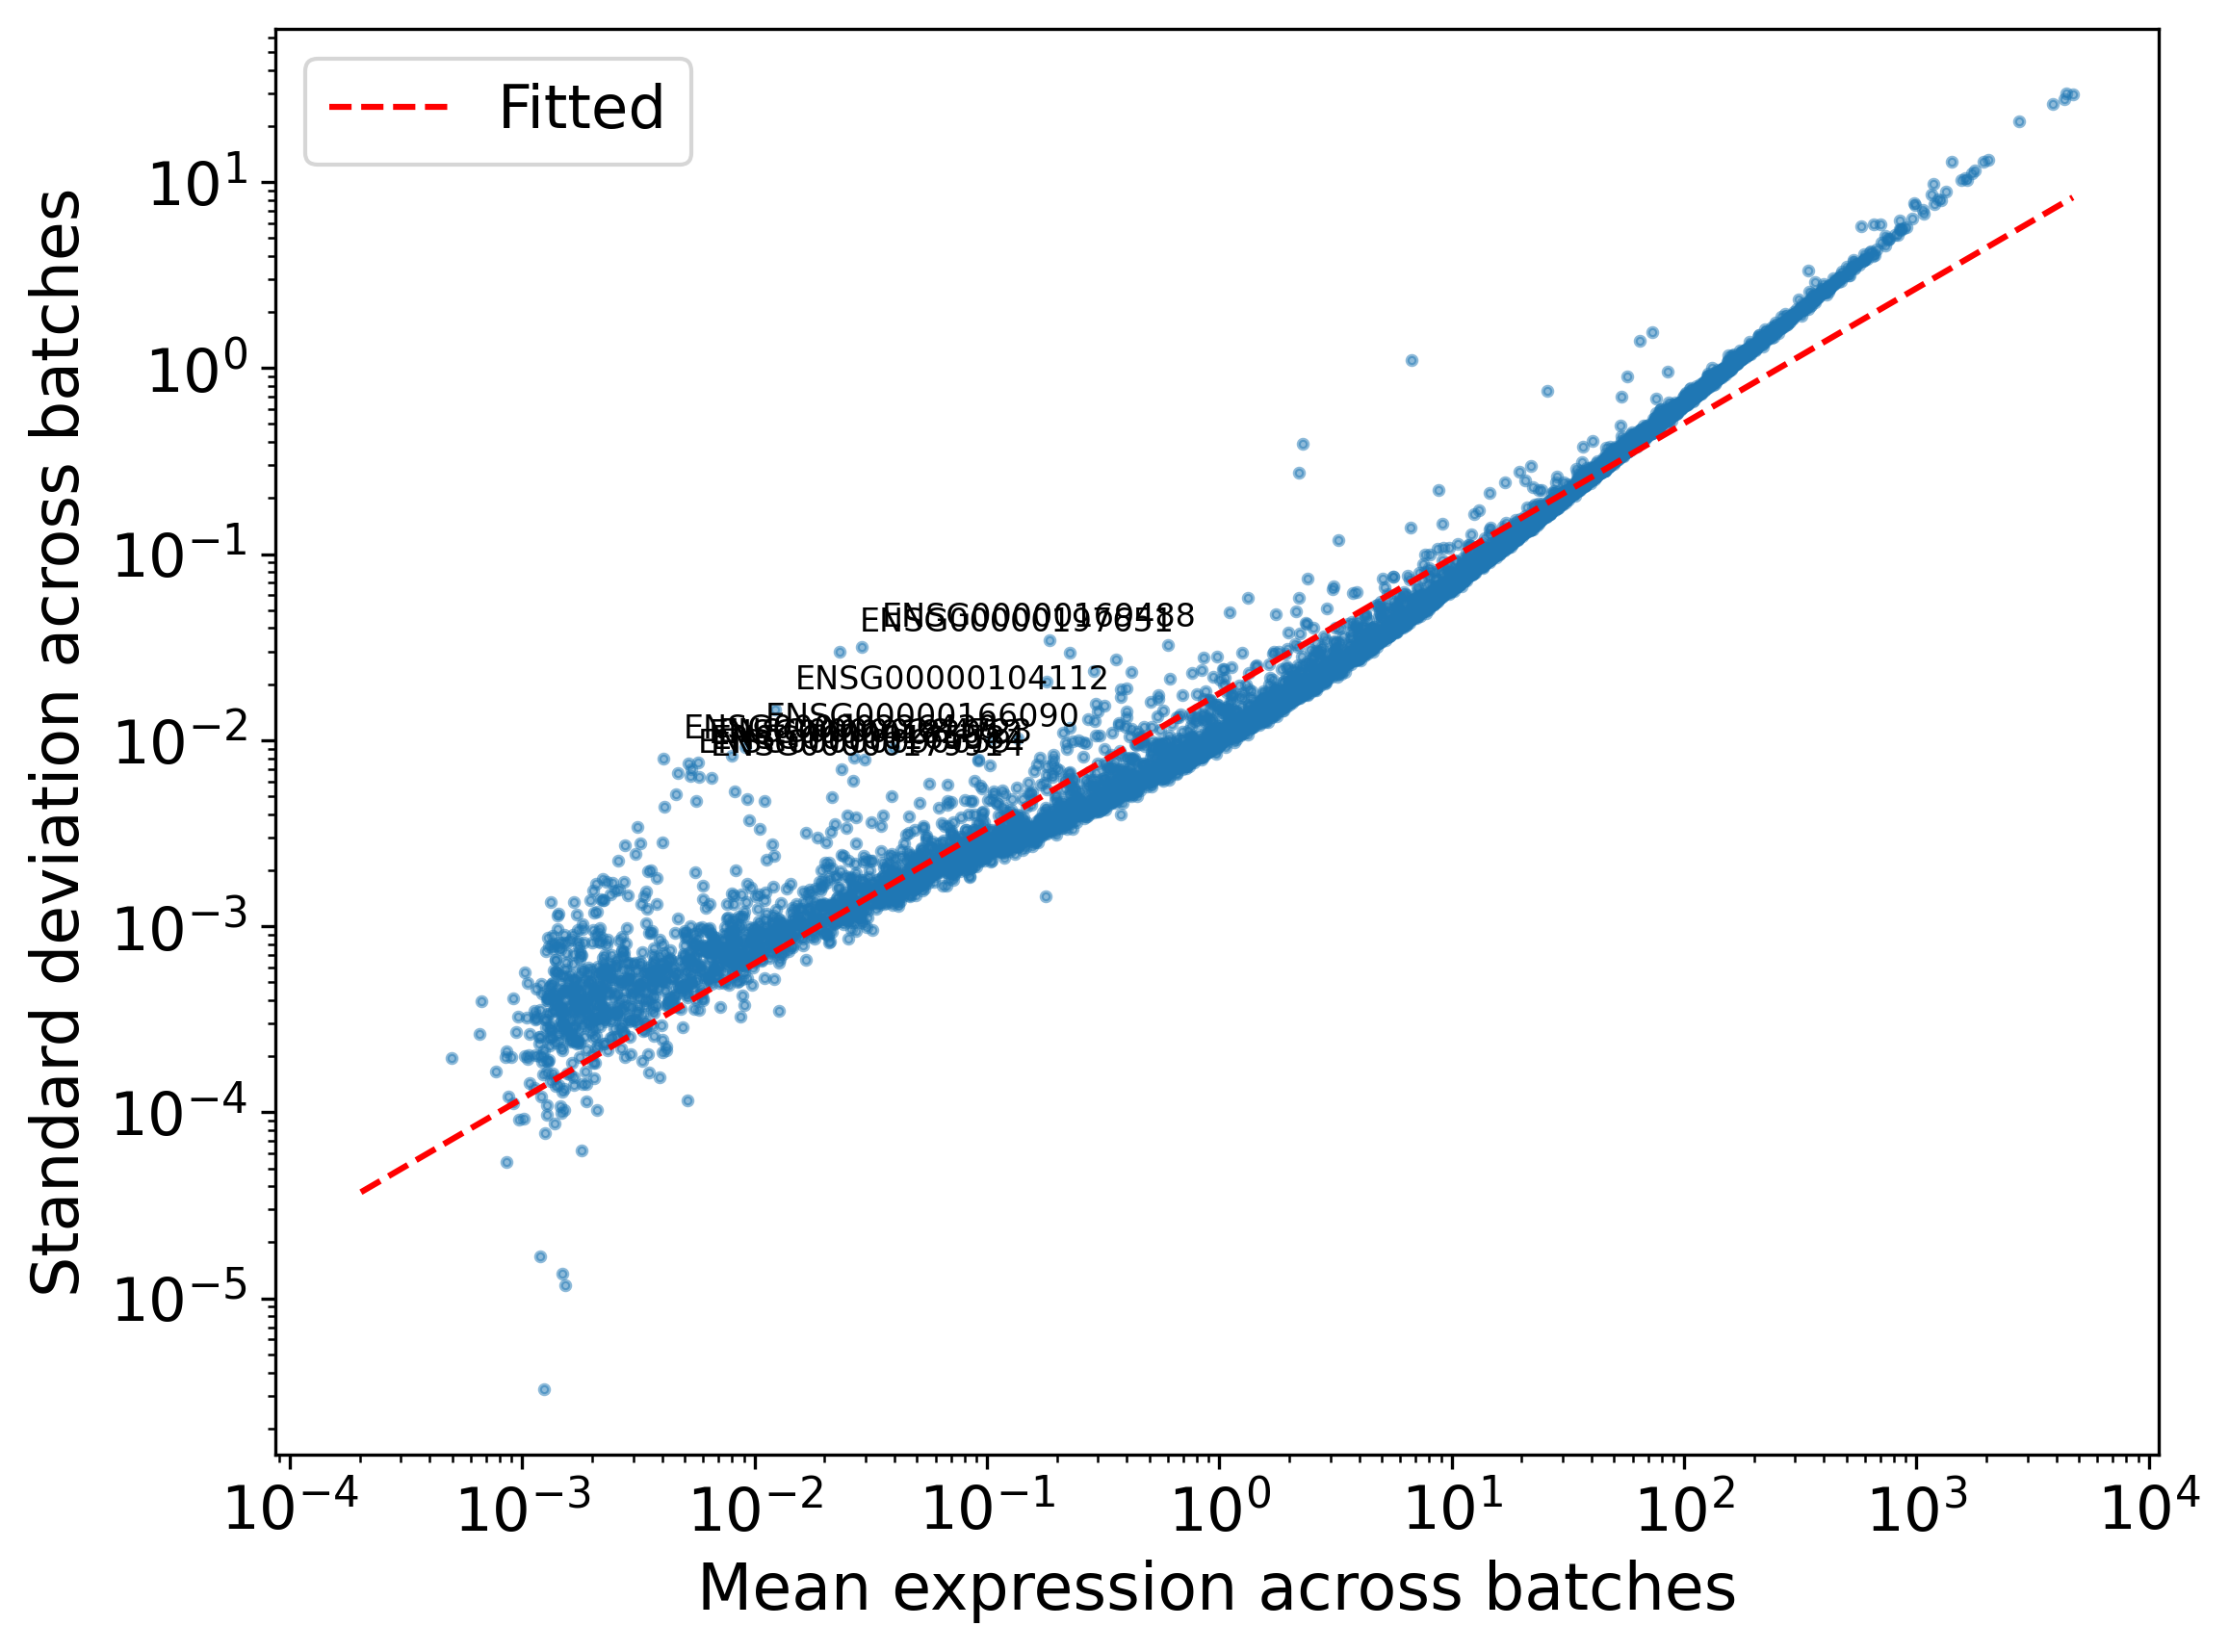

In [59]:
# Calculate mean and standard deviation across batches
mean_values = base_mean_stim.mean(1)
std_values = base_mean_stim.std(1)

# Plot all points
plt.figure(figsize=(8, 6))
plt.scatter(mean_values, std_values, alpha=0.5, s=5)

# Fit a power law relationship between mean and std (std ~ mean^alpha)
# Use log-log space for linear fitting
valid_points = (mean_values > 0) & (std_values > 0)
log_mean = np.log(mean_values[valid_points])
log_std = np.log(std_values[valid_points])
fit = np.polyfit(log_mean, log_std, 1)
alpha = fit[0]  # Power law exponent
const = np.exp(fit[1])  # Multiplicative constant

# Generate fitted line
x_range = np.logspace(np.log10(mean_values.min()), np.log10(mean_values.max()), 100)
fitted_std = const * (x_range ** alpha)
plt.plot(x_range, fitted_std, 'r--', 
         label=f'Fitted')

# Identify outliers based on fitted relationship
expected_std = const * (mean_values ** alpha)
outliers = std_values > (expected_std * 2)  # Points with std > 2x expected
outlier_indices = np.where(outliers)[0]

# Annotate top 10 outliers
if len(outlier_indices) > 0:
    # Sort outliers by deviation from expected
    deviation = std_values[outliers] / expected_std[outliers]
    top_outliers = outlier_indices[np.argsort(deviation)[-10:]]
    
    for idx in top_outliers:
        gene_name = base_mean_stim.index[idx]
        plt.annotate(gene_name, 
                    (mean_values.iloc[idx], std_values.iloc[idx]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean expression across batches')
plt.ylabel('Standard deviation across batches')
plt.legend()
plt.tight_layout()


In [60]:
adata_de.var['mean_baseMean_Rest'] = base_mean_rest.mean(1).fillna(0)
adata_de.var['std_baseMean_Rest'] = base_mean_rest.std(1).fillna(10000)

adata_de.var['mean_baseMean_Stim8hr'] = base_mean_stim.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim8hr'] = base_mean_stim.std(1).fillna(10000)

adata_de.var['mean_baseMean_Stim48hr'] = base_mean_stim48.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim48hr'] = base_mean_stim48.std(1).fillna(10000)

## Power on lowly-expressed genes

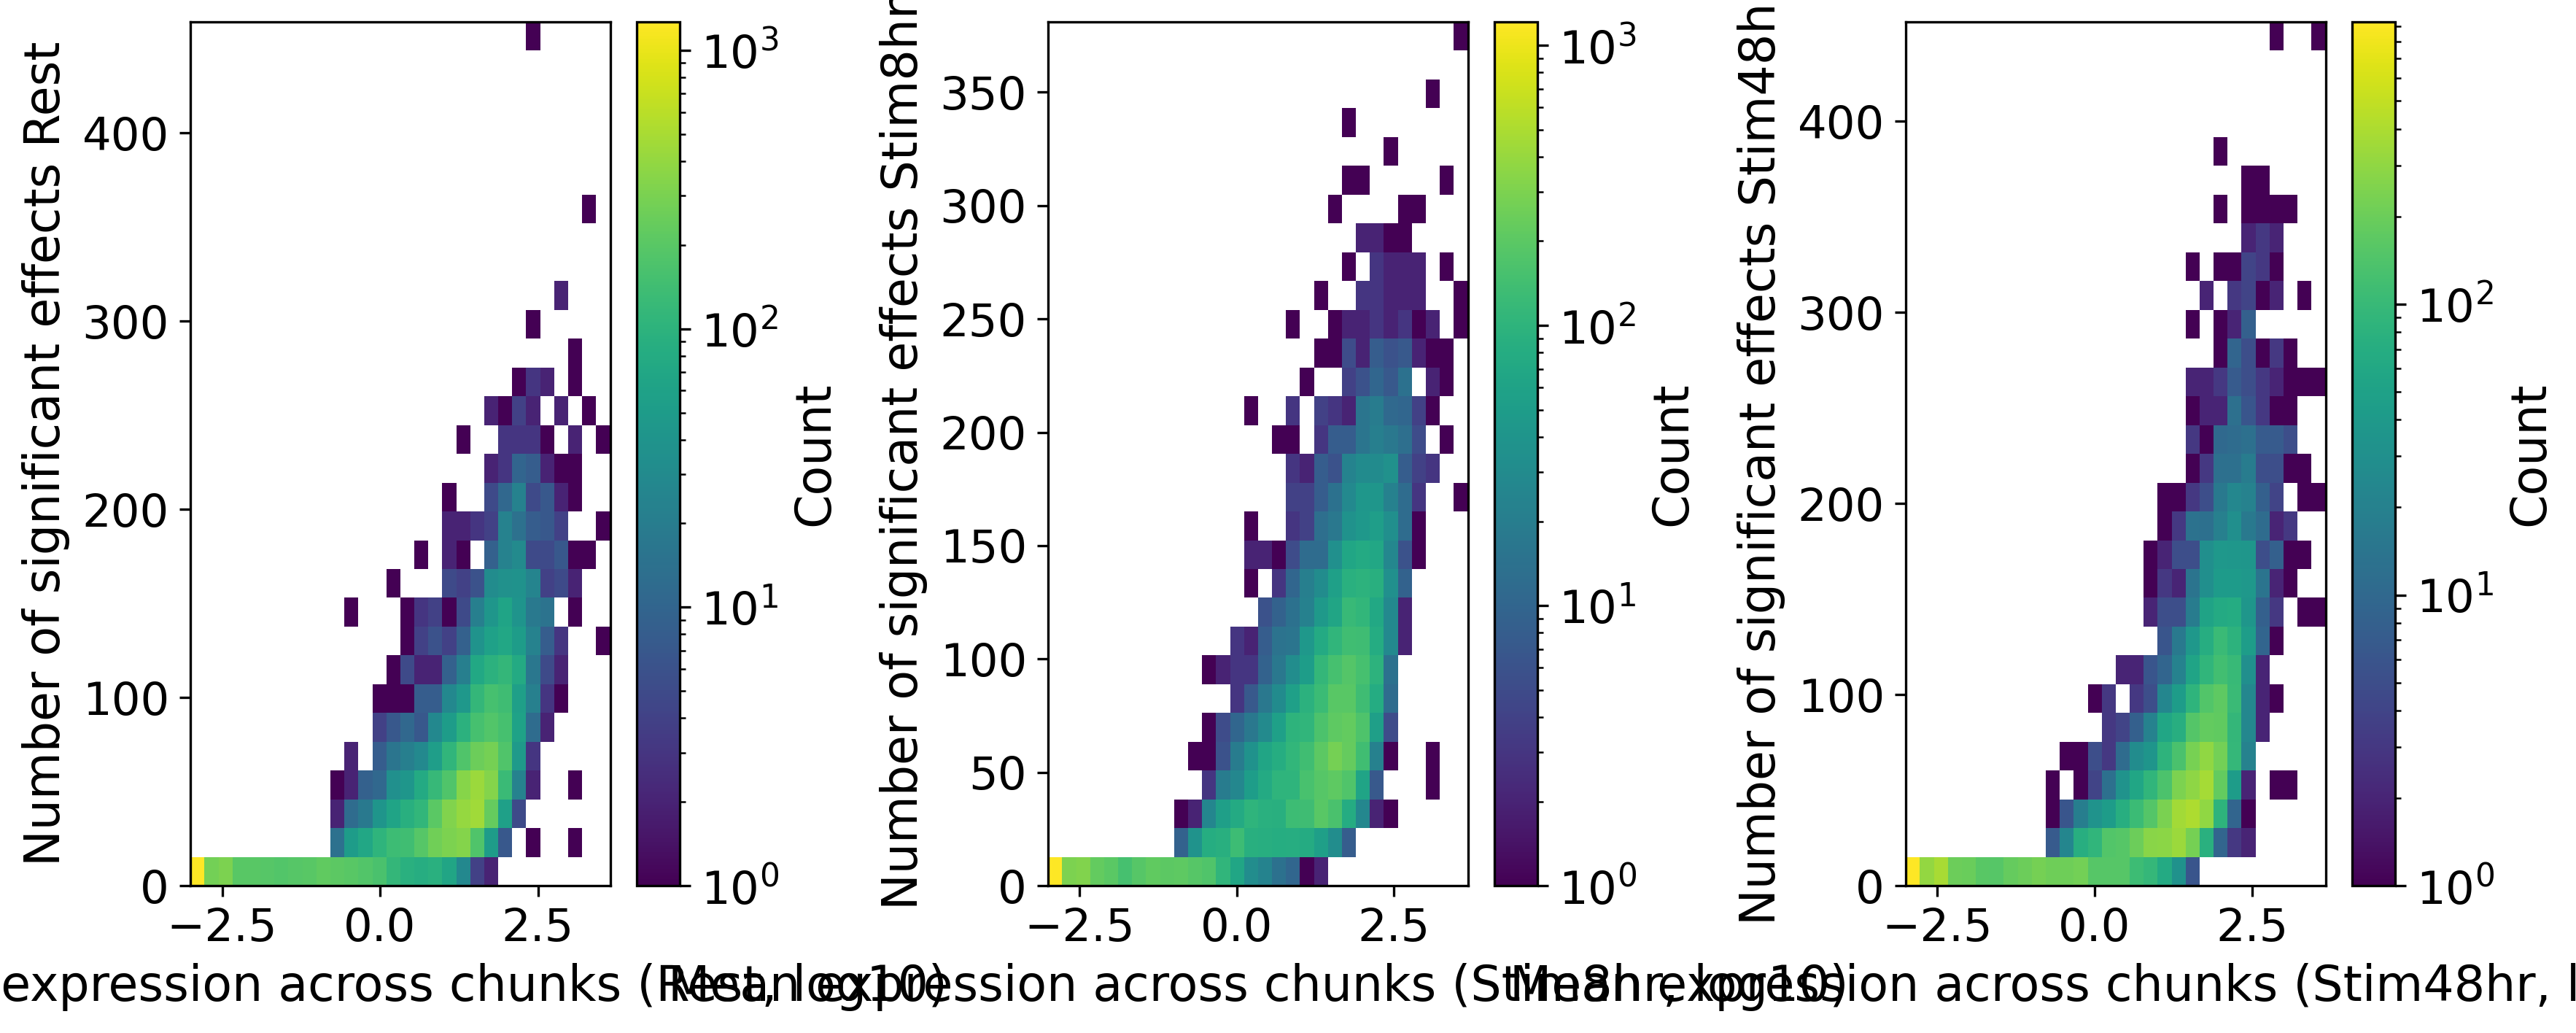

In [61]:
plt.figure(figsize=(12,5))
for i,cond in enumerate(['Rest', 'Stim8hr', 'Stim48hr']):
    plt.subplot(1,3,i+1)
    plt.hist2d(
        np.log10(adata_de.var[f'mean_baseMean_{cond}']+0.001), 
        adata_de.var[f'n_signif_effects_{cond}'],
        bins=30, 
        norm=matplotlib.colors.LogNorm()
    )
    plt.colorbar(label='Count')
    # plt.xscale('log')
    plt.xlabel(f'Mean expression across chunks ({cond}, log10)')
    plt.ylabel(f'Number of significant effects {cond}')
plt.tight_layout()


Text(0, 0.5, 'Mean baseMean Rest')

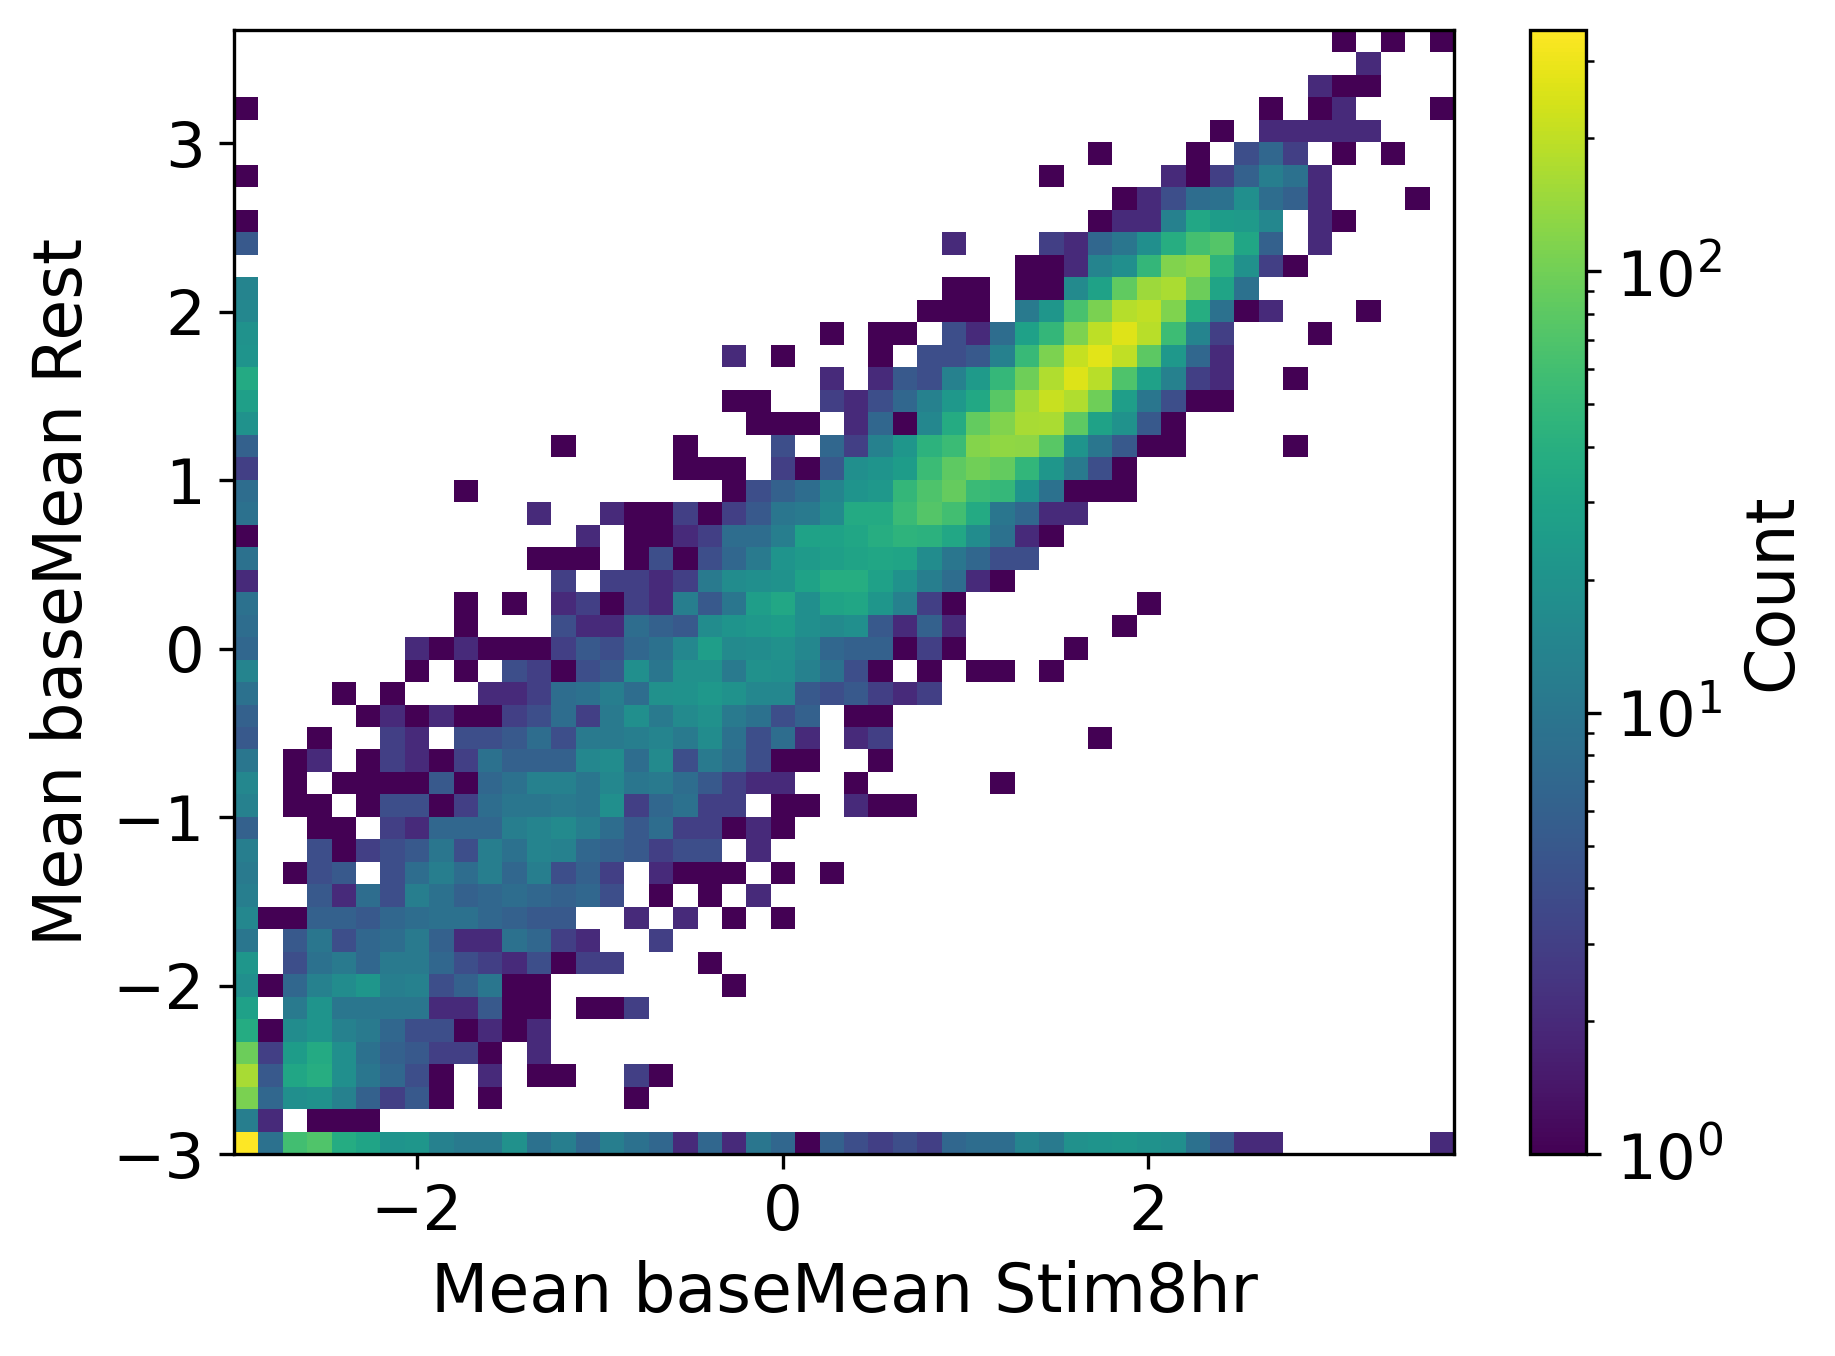

In [62]:
plt.hist2d(
    np.log10(adata_de.var['mean_baseMean_Stim8hr']+0.001), 
    np.log10(adata_de.var['mean_baseMean_Stim48hr']+0.001), 
    bins=50, 
    norm=matplotlib.colors.LogNorm()
)
plt.colorbar(label='Count')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Mean baseMean Stim8hr')
plt.ylabel('Mean baseMean Rest')

In [63]:
# Exclude from analysis genes with very low base mean across conditions
gs_mask = (adata_de.var['mean_baseMean_Stim8hr'] > 0.1) & (adata_de.var['mean_baseMean_Stim48hr'] > 0.1) & (adata_de.var['mean_baseMean_Rest'] > 0.1) 
sum(~gs_mask)

3677

In [64]:
sum(gs_mask)

10282

In [65]:
adata_de = adata_de[:, gs_mask].copy()

In [66]:
adata_de.obs['culture_condition'].value_counts()

culture_condition
Stim8hr     11416
Rest        11288
Stim48hr    11282
Name: count, dtype: int64

## On-target effect

Compare DESeq2 estimates with knock-down efficiency estimated with t-test

In [67]:
adata_de.var_names = adata_de.var['gene_ids'].values

In [27]:
conditions = ['Rest', 'Stim8hr', 'Stim48hr']
ontarget_df = pd.DataFrame()
for culture_condition in conditions:
    # Get on-target effects for this condition
    ontarget_df_c = get_ontarget_effect(
            adata_de[adata_de.obs['culture_condition'] == culture_condition], 
            signif_estimate='adj_p_value',
            signif_alpha=0.1
        )
    ontarget_df_c['culture_condition'] = culture_condition
    ontarget_df = pd.concat([ontarget_df, ontarget_df_c])

In [28]:
ontarget_df.value_counts('culture_condition')

culture_condition
Stim8hr     9441
Rest        9353
Stim48hr    9339
Name: count, dtype: int64

In [29]:
ontarget_df.significant.sum()/ontarget_df.shape[0]

0.733018163722319

In [30]:
ontarget_df.to_csv(f'{datadir}/DE_results_all_confounders/on_target_effects.csv')

In [68]:
ontarget_df = pd.read_csv(f'{datadir}/DE_results_all_confounders/on_target_effects.csv', index_col=0)
ontarget_df['significant'] = np.where(ontarget_df['adj_p_value'].isna(), np.nan, ontarget_df['significant']) #.astype(bool)
ontarget_df['significant'] = np.where(ontarget_df['zscore'] > 0, False, ontarget_df['significant']) #.astype(bool)
ontarget_df[0:50]

,index,gene,log_fc,zscore,baseMean,adj_p_value,significant,gene_name,culture_condition,target_contrast
0,ENSG00000000419_Rest,ENSG00000000419,-1.703465,-17.612309,89.948299,1.975769e-65,1.0,DPM1,Rest,ENSG00000000419
9354,ENSG00000000457_Rest,ENSG00000000457,-1.048135,-4.930968,23.079312,1.392359e-03,1.0,SCYL3,Rest,ENSG00000000457
18708,ENSG00000000460_Rest,ENSG00000000460,-2.294418,-13.726757,53.395050,8.688725e-39,1.0,C1orf112,Rest,ENSG00000000460
28062,ENSG00000000971_Rest,ENSG00000000971,-1.262355,-1.083118,1.183110,9.999999e-01,0.0,CFH,Rest,ENSG00000000971
37416,ENSG00000001036_Rest,ENSG00000001036,-3.221094,-7.333048,12.932647,2.782497e-09,1.0,FUCA2,Rest,ENSG00000001036
46770,ENSG00000001084_Rest,ENSG00000001084,-0.953776,-4.189575,33.873505,8.433609e-02,1.0,GCLC,Rest,ENSG00000001084
56124,ENSG00000001460_Rest,ENSG00000001460,-3.768580,-4.091180,4.646765,1.271895e-01,0.0,STPG1,Rest,ENSG00000001460
65478,ENSG00000001461_Rest,ENSG00000001461,-3.164955,-18.723402,52.436546,3.947973e-74,1.0,NIPAL3,Rest,ENSG00000001461
74832,ENSG00000001561_Rest,ENSG00000001561,-2.884658,-7.073232,11.330025,1.873308e-08,1.0,ENPP4,Rest,ENSG00000001561
84186,ENSG00000001630_Rest,ENSG00000001630,-2.836041,-6.919963,42.466708,5.591444e-08,1.0,CYP51A1,Rest,ENSG00000001630


Plot figures

In [47]:
ontarget_df[effect_col].max()

7.091937721582496

/tmp/ipykernel_2667279/1868353849.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


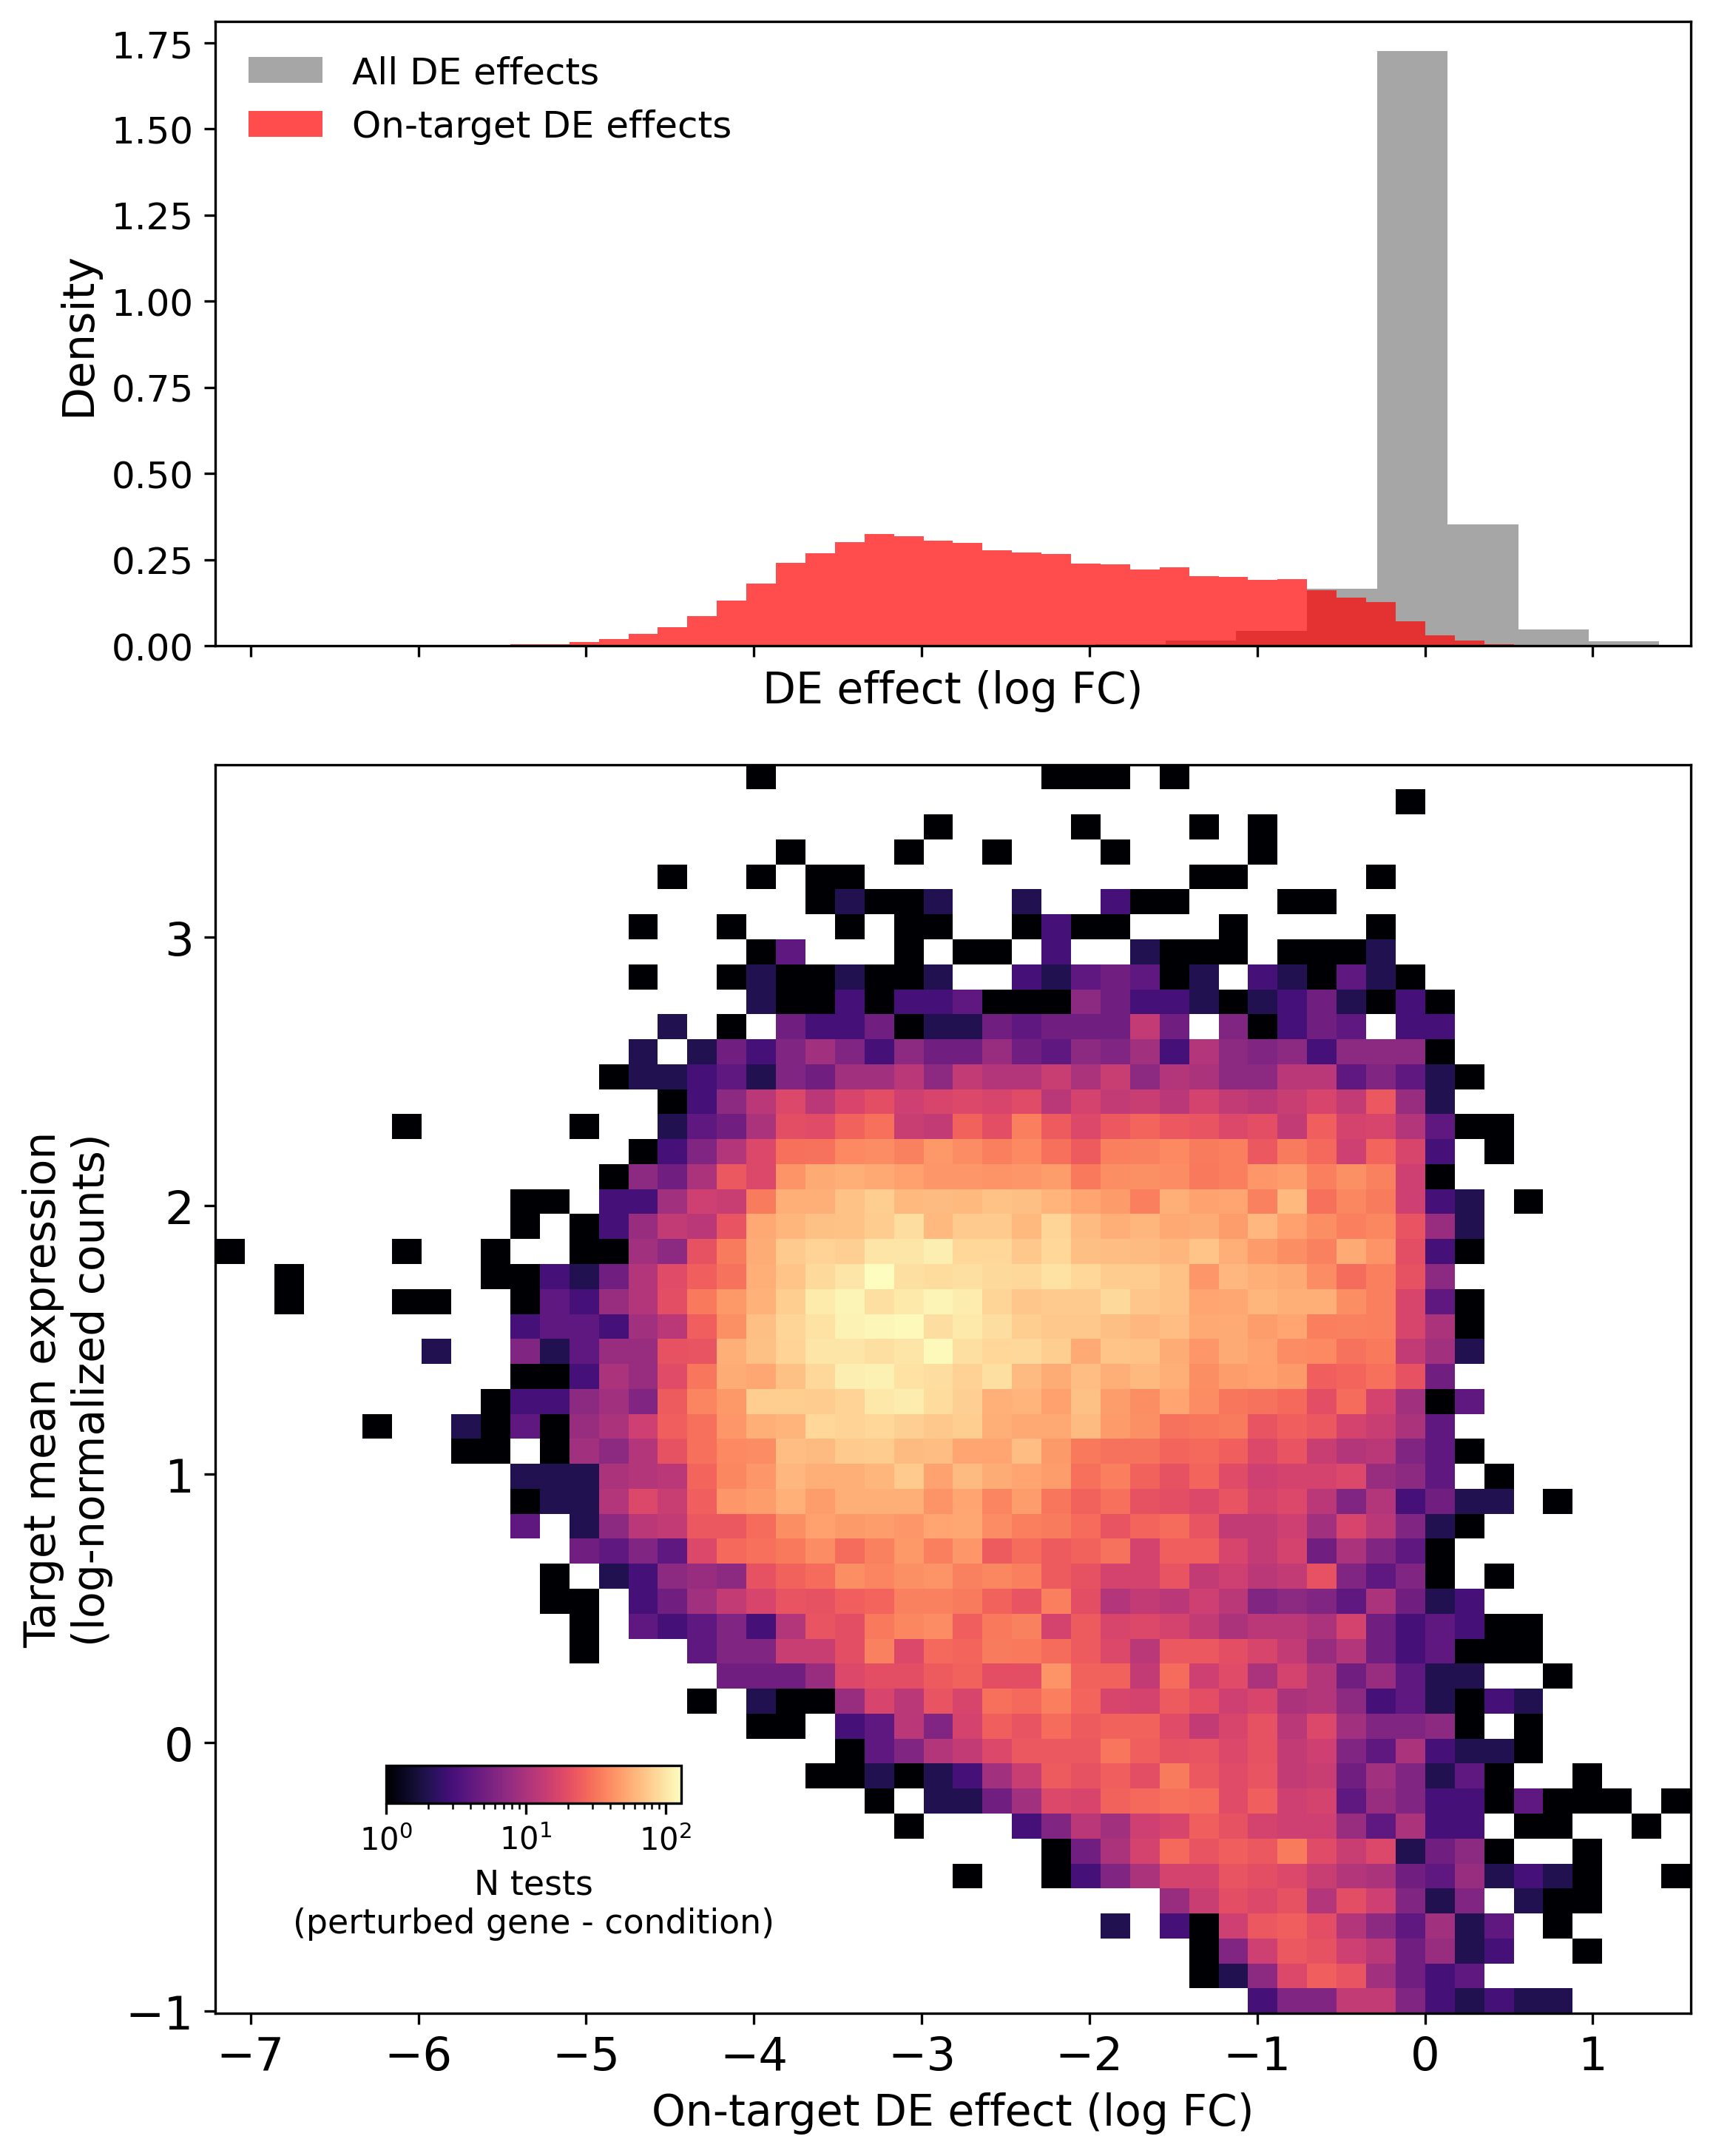

In [117]:
effect_col = 'log_fc'

fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=(1,2), figsize=(8, 10), sharex=True)

x_min = ontarget_df[effect_col].min()
x_max = ontarget_df[effect_col].max()

# histogram
all_effects = adata_de.layers[effect_col].flatten()
ontarget_effects = ontarget_df[effect_col]
ax1.hist(all_effects, bins=100, density=True, alpha=0.7, color='grey', label='All DE effects')
ax1.hist(ontarget_effects, bins=50, density=True, alpha=0.7, color='red', label='On-target DE effects')
ax1.set_ylabel('Density', fontsize=14)
ax1.set_xlabel('DE effect (log FC)', fontsize=14)
ax1.tick_params(labelsize=12)
ax1.legend(fontsize=12, frameon=False)
ax1.set_xlim(x_min, x_max)

# 2D histogram of effect size vs expression
y_min = np.log10(ontarget_df['baseMean'].min())
y_max = np.log10(ontarget_df['baseMean'].max())

h = ax2.hist2d(
    ontarget_df[effect_col],
    np.log10(ontarget_df['baseMean']),
    bins=50,
    norm=matplotlib.colors.LogNorm(),
    cmap='magma',
    range=[[x_min, x_max], [y_min, y_max]]
)

ax2.set_xlabel('On-target DE effect (log FC)', fontsize=14)
ax2.set_ylabel('Target mean expression\n(log-normalized counts)', fontsize=14)

# colorbar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cbar_ax = inset_axes(ax2, width="20%", height="3%", loc='lower left', 
                     bbox_to_anchor=(0.1, 0.15, 1, 1), bbox_transform=ax2.transAxes)
cbar = plt.colorbar(h[3], cax=cbar_ax, orientation='horizontal')
cbar.set_label('N tests\n(perturbed gene - condition)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("results/ontarget_DE_figure.pdf")
plt.savefig("results/ontarget_DE_figure.png")

/tmp/ipykernel_3498615/1347464326.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


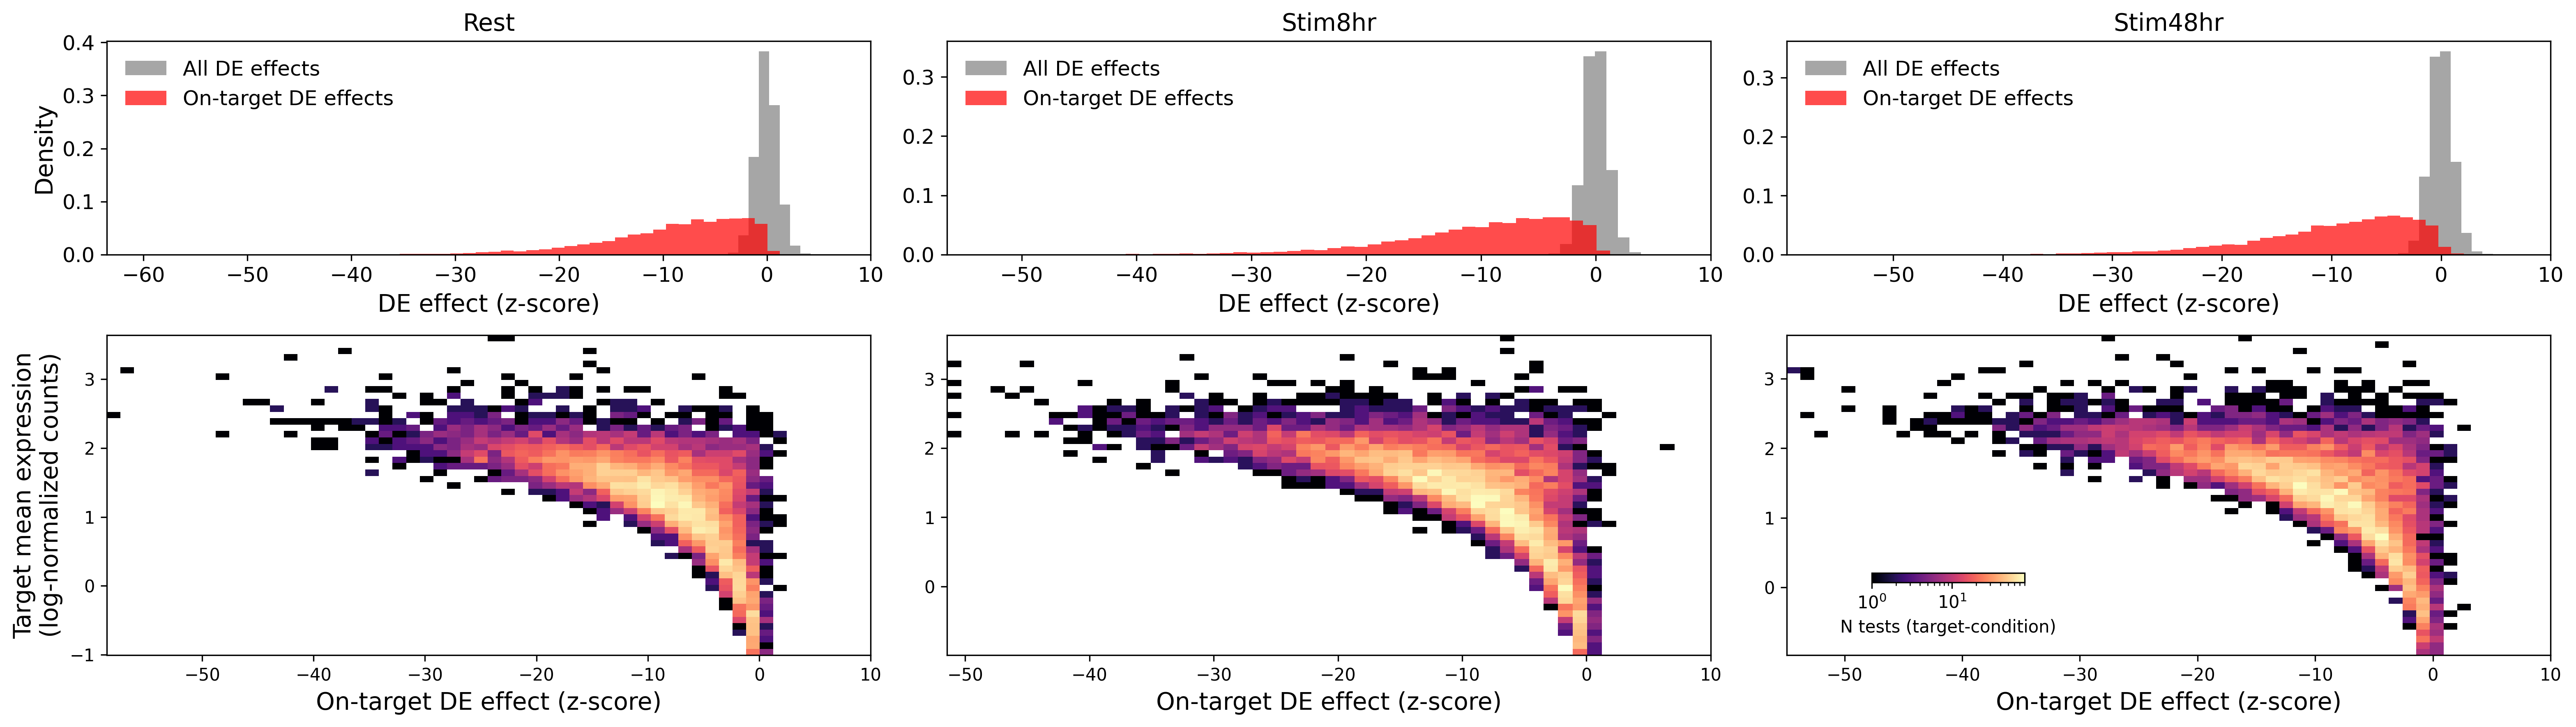

In [33]:
effect_col = 'zscore'

conditions = ontarget_df['culture_condition'].unique()
n_conditions = len(conditions)

fig, axes = plt.subplots(2, n_conditions, figsize=(7*n_conditions, 6), 
                        height_ratios=[1, 1.5])

for i, condition in enumerate(conditions):
    condition_mask = ontarget_df['culture_condition'] == condition
    condition_data = ontarget_df[condition_mask]
    
    # histogram
    all_effects = adata_de.layers[effect_col][adata_de.obs['culture_condition'] == condition].flatten()
    ontarget_effects = condition_data[effect_col]
    
    axes[0,i].hist(all_effects, bins=100, density=True, alpha=0.7, color='grey', label='All DE effects')
    axes[0,i].hist(ontarget_effects, bins=50, density=True, alpha=0.7, color='red', label='On-target DE effects')
    axes[0,i].set_ylabel('Density' if i==0 else '', fontsize=14)
    axes[0,i].set_xlabel('DE effect (z-score)', fontsize=14)
    axes[0,i].tick_params(labelsize=12)
    axes[0,i].legend(fontsize=12, frameon=False)
    axes[0,i].set_title(condition, fontsize=14)

    # 2D histogram
    y_min = np.log10(condition_data['baseMean'].min())
    y_max = np.log10(condition_data['baseMean'].max())
    x_min = condition_data[effect_col].min()
    x_max = condition_data[effect_col].max()

    h = axes[1,i].hist2d(
        condition_data[effect_col],
        np.log10(condition_data['baseMean']),
        bins=50,
        norm=matplotlib.colors.LogNorm(),
        cmap='magma',
        range=[[x_min, x_max], [y_min, y_max]]
    )

    axes[1,i].set_xlabel('On-target DE effect (z-score)', fontsize=14)
    axes[1,i].set_ylabel('Target mean expression\n(log-normalized counts)' if i==0 else '', fontsize=14)

    axes[0,i].set_xlim(right=10)
    axes[1,i].set_xlim(right=10)

    # colorbar
    if i == n_conditions-1:
        cbar_ax = inset_axes(axes[1,i], width="20%", height="3%", loc='lower left',
                            bbox_to_anchor=(0.1, 0.2, 1, 1), bbox_transform=axes[1,i].transAxes)
        cbar = plt.colorbar(h[3], cax=cbar_ax, orientation='horizontal', 
                           label='N tests (target-condition)')
        cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("results/ontarget_DE_figure_by_condition.pdf")
plt.savefig("results/ontarget_DE_figure_by_condition.png")

<Axes: xlabel='zscore', ylabel='min_effect_size'>

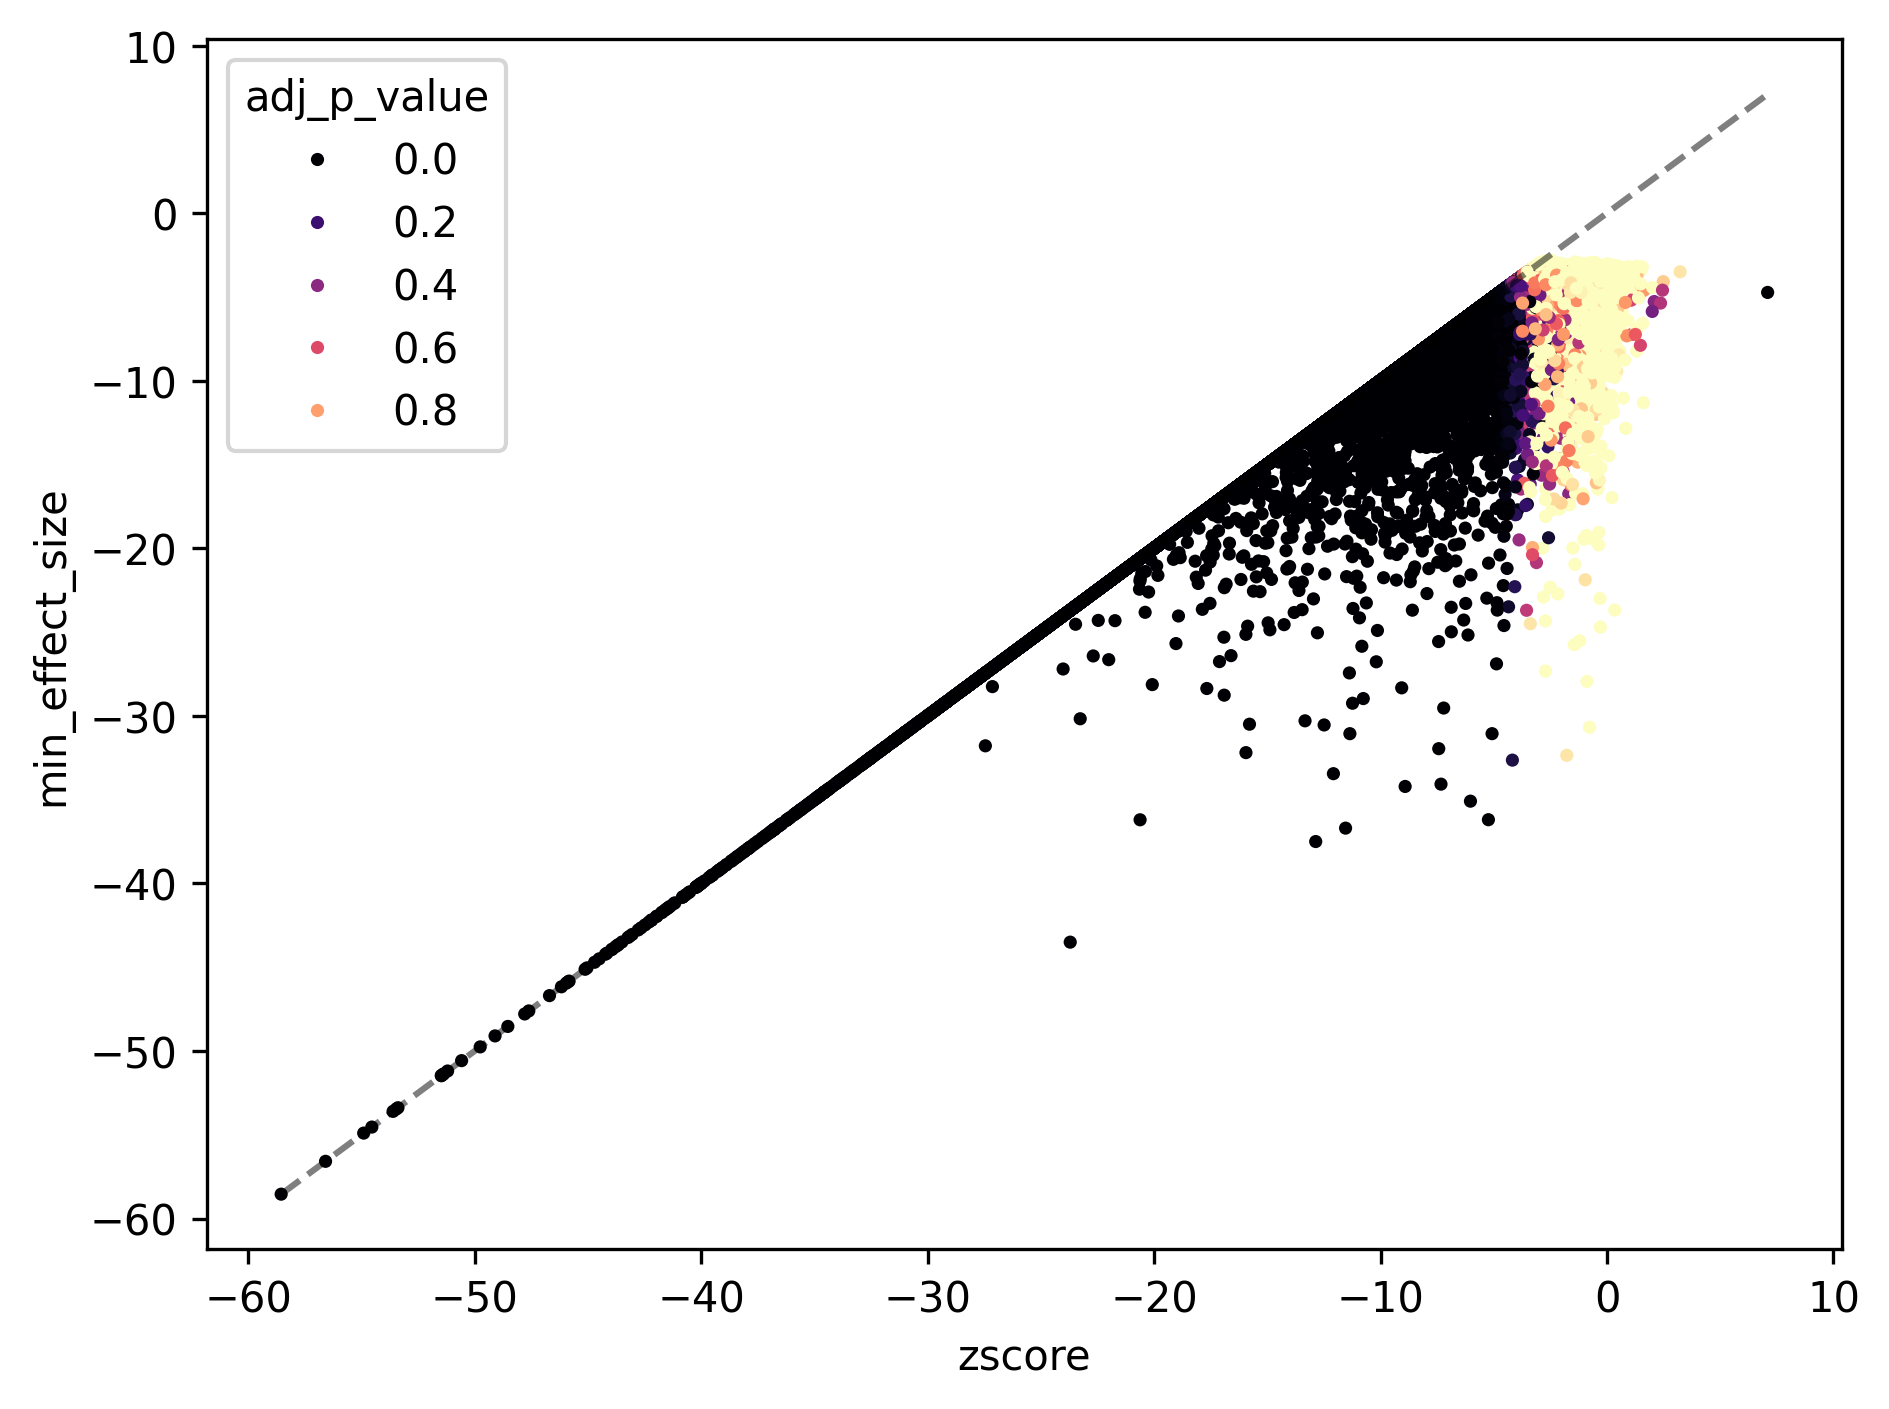

In [34]:
min_effect_gene = adata_de.var.iloc[np.argmin(adata_de.layers['zscore'], axis=1)]['gene_name']
min_effect_size = np.min(adata_de.layers['zscore'], axis=1)
min_effect_df = pd.DataFrame(np.column_stack([adata_de.obs['culture_condition'].values, adata_de.obs['target_contrast'].values, min_effect_gene.values, min_effect_size]), 
             columns=['culture_condition','target_contrast','min_effect_gene', 'min_effect_size'])

pl_df = pd.merge(ontarget_df, min_effect_df)

# Add diagonal line first so it appears under the points
x_min = pl_df['zscore'].min()
x_max = pl_df['zscore'].max()
plt.plot([x_min, x_max], [x_min, x_max], 'k--', alpha=0.5)

# Plot the scatter with magma color scale
sns.scatterplot(data=pl_df, x='zscore', y='min_effect_size', 
                hue='adj_p_value', s=10, linewidth=0, palette='magma')

### Evidence for off-target in close genes

Read detailed annotation 

In [69]:
sgRNA_library_orig = pd.read_csv('../../metadata/sgRNA_library_curated.csv').rename({'sgrna_id':'sgRNA'}, axis=1)
sgRNA_library_curated = pd.read_parquet('../../metadata/sgrna_df_final.parquet')

# Add original perturbed gene id from orig table to curated table
sgRNA_library_curated['original_perturbed_gene_id'] = sgRNA_library_curated['sgRNA'].map(
    sgRNA_library_orig.set_index('sgRNA')['perturbed_gene_id']
)

sgRNA_library_curated.head()

,sgRNA,chromosome,pos,seq_last19bp,strand,PAM,note,flag,seq,target_gene_name_from_sgRNA,...,nearest_within2kb_nontarget_gene_id,nearest_within2kb_nontarget_gene_name,nearest_within2kb_nontarget_gene_dist,putative_bidirectional_promoter,other_alignment_chromosome,other_alignment_pos,nearest_nontarget_gene_id,nearest_nontarget_gene_name,nearest_nontarget_gene_dist,original_perturbed_gene_id
0,ARMC5-1,chr16,31459566,TGCCTCGCGCAGCTCGCGG,+,True,"unique alignment, aligned to a cds but far fro...",True,CTGCCTCGCGCAGCTCGCGG,ARMC5,...,None,None,NaN,False,None,None,ENSG00000140682,TGFB1I1,12019.0,ENSG00000140691
1,DDB1-1,chr11,61333047,GAGTTCGCTGCGCGCTGTT,-,True,"unique alignment, aligned to a cds but far fro...",True,GGAGTTCGCTGCGCGCTGTT,DDB1,...,ENSG00000149476,TKFC,174.0,True,None,None,ENSG00000149476,TKFC,174.0,ENSG00000167986
2,FNDC10-1,chr1,1600078,GCCCGCTCCCCGCGATCCC,+,True,"unique alignment, aligned to a cds but far fro...",True,TGCCCGCTCCCCGCGATCCC,FNDC10,...,None,None,NaN,False,None,None,ENSG00000197530,MIB2,15422.0,ENSG00000228594
3,RORC-1,chr1,151831746,CTGTGGGGCCCTGTCCATG,+,True,"unique alignment, aligned to a cds but far fro...",True,TCTGTGGGGCCCTGTCCATG,RORC,...,None,None,NaN,False,None,None,ENSG00000225556,C2CD4D,8074.0,ENSG00000143365
4,SLC35F6-1,chr2,26764356,AACAGCTGGTACTTGGTCC,-,True,"unique alignment, aligned to a cds but far fro...",True,GAACAGCTGGTACTTGGTCC,SLC35F6,...,ENSG00000115163,CENPA,67.0,False,None,None,ENSG00000115163,CENPA,67.0,ENSG00000213699


In [70]:
mean_dist_2_closest_tss = sgRNA_library_curated[['target_gene_name_from_sgRNA','nearest_nontarget_gene_dist']].groupby('target_gene_name_from_sgRNA')['nearest_nontarget_gene_dist'].mean()
print((mean_dist_2_closest_tss < 5000).value_counts())
print((mean_dist_2_closest_tss < 5000).value_counts()/mean_dist_2_closest_tss.shape[0])

nearest_nontarget_gene_dist
False    9123
True     3659
Name: count, dtype: int64
nearest_nontarget_gene_dist
False    0.713738
True     0.286262
Name: count, dtype: float64


In [71]:
closest_gene_df = (sgRNA_library_curated[['original_perturbed_gene_id', 'nearest_nontarget_gene_id', 'nearest_nontarget_gene_dist']]
                  .sort_values('nearest_nontarget_gene_dist')
                  .groupby('original_perturbed_gene_id')
                  .first()
                  .reset_index())
closest_id = closest_gene_df[['original_perturbed_gene_id', 'nearest_nontarget_gene_id']].set_index('original_perturbed_gene_id')
closest_dist = closest_gene_df[['original_perturbed_gene_id', 'nearest_nontarget_gene_dist']].set_index('original_perturbed_gene_id')

all_closest_genes_effect = pd.DataFrame()

from tqdm.notebook import tqdm
for t in tqdm(ontarget_df.target_contrast.unique(), desc="Processing targets"):
    # Get DE results for closest genes to this target
    closest_genes_effect = get_DE_results_long(
        adata_de,
        targets=[t], genes=closest_id.loc[t], 
        effect_estimates = ['zscore'],
        signif_estimate = 'adj_p_value',
        target_id_col = 'target_contrast',
        gene_id_col='gene_ids'
    )
    
    # Get distance information for this target
    closest_genes_effect['distance'] = closest_dist.loc[t]['nearest_nontarget_gene_dist']
    closest_genes_effect['rank'] = 1
    
    # Concatenate to main results dataframe
    all_closest_genes_effect = pd.concat([all_closest_genes_effect, closest_genes_effect])

# Add on-target effects
all_ontarget_effect = ontarget_df.copy()
all_ontarget_effect['distance'] = 0
all_ontarget_effect['rank'] = 0
all_ontarget_effect = pd.concat([all_ontarget_effect, all_closest_genes_effect]).sort_values(['target_contrast', 'rank'])

Processing targets:   0%|          | 0/9498 [00:00<?, ?it/s]

/tmp/ipykernel_1370790/1067619995.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_closest_genes_effect = pd.concat([all_closest_genes_effect, closest_genes_effect])
/tmp/ipykernel_1370790/1067619995.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_closest_genes_effect = pd.concat([all_closest_genes_effect, closest_genes_effect])
/tmp/ipykernel_1370790/1067619995.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future 

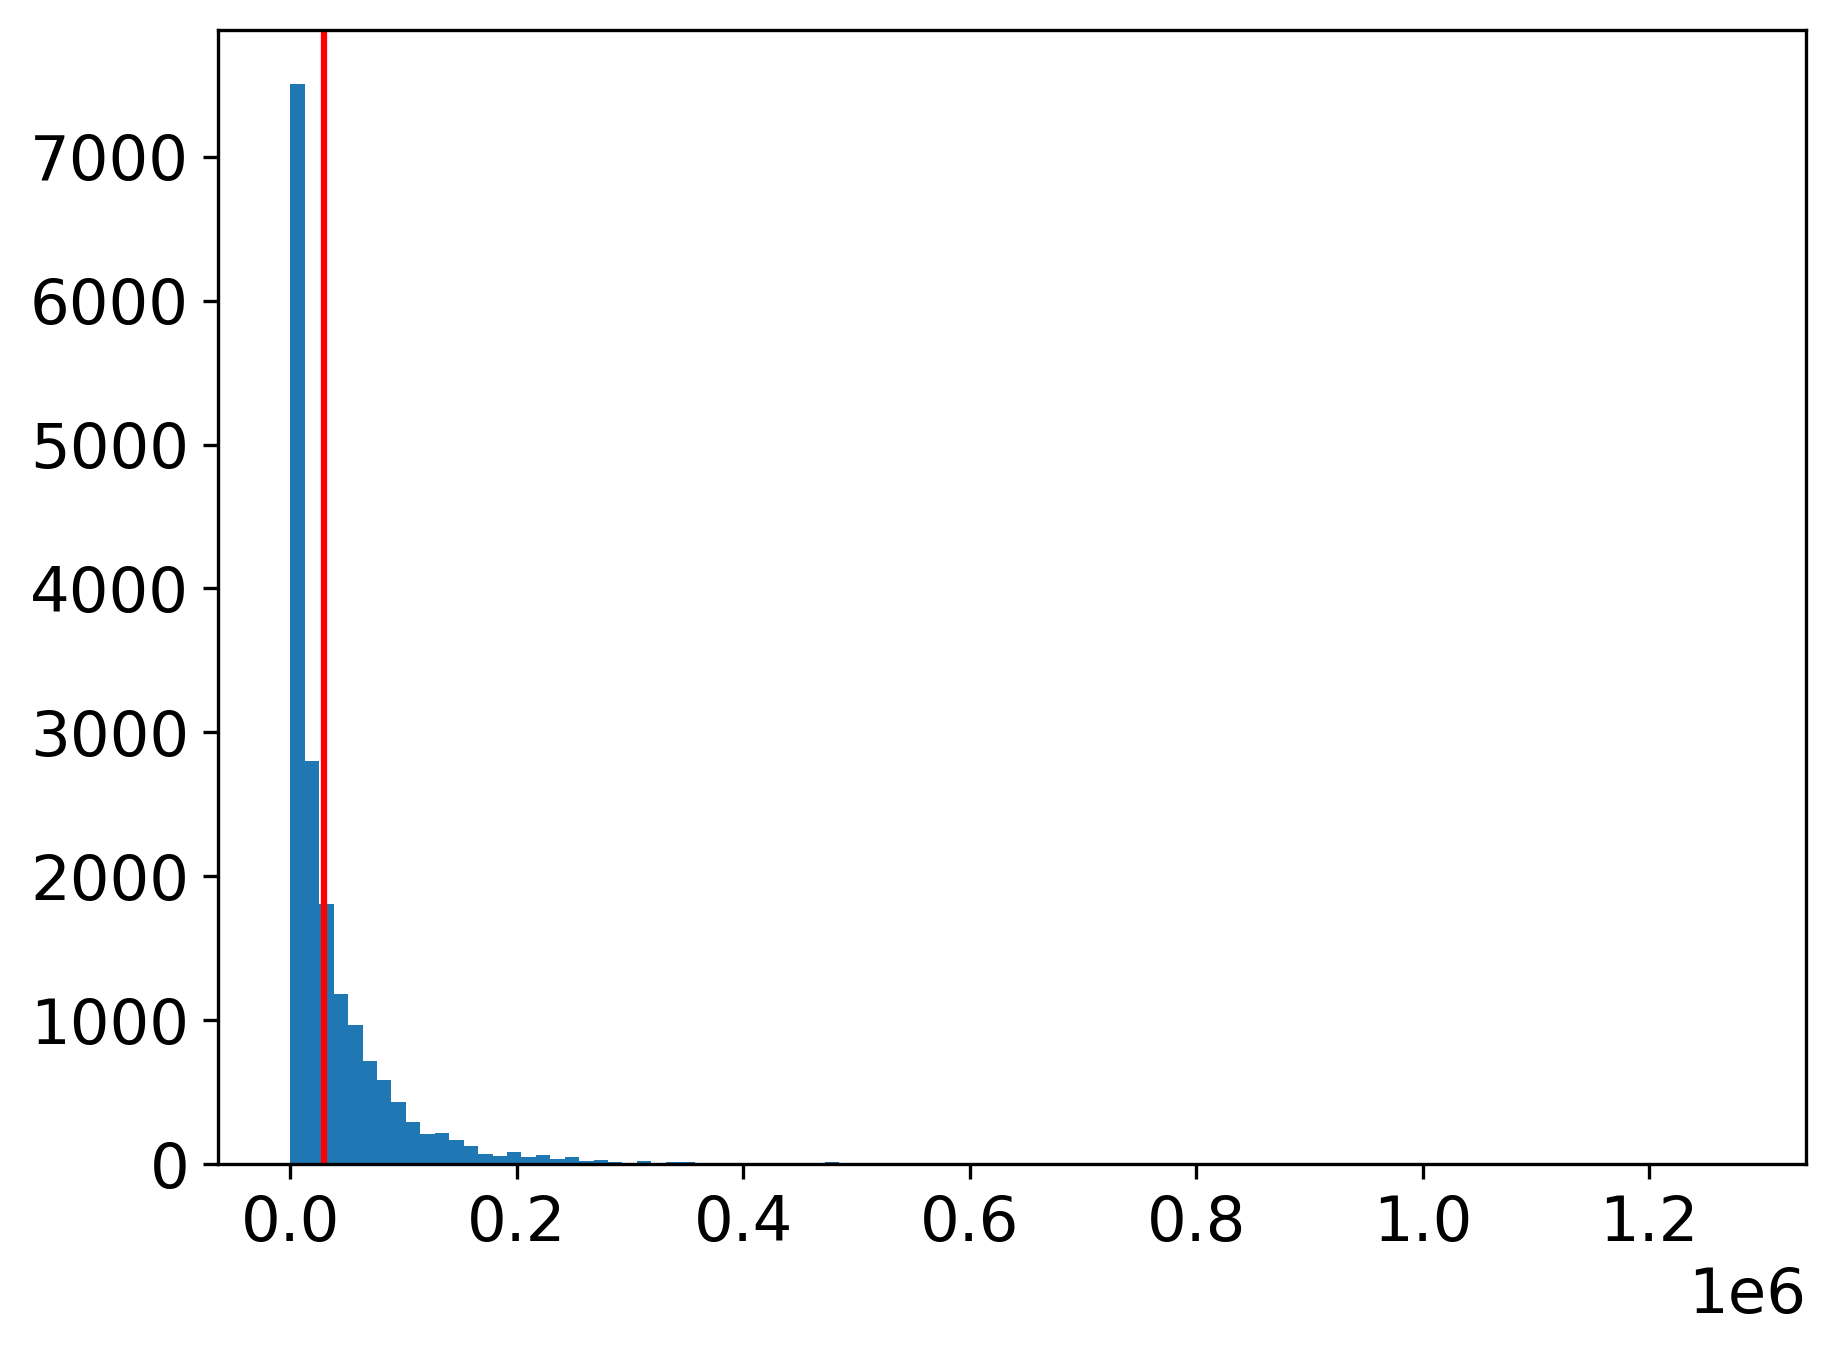

In [72]:
plt.hist(all_ontarget_effect[all_ontarget_effect['rank'] > 0].distance, bins=100);
plt.axvline(30000, color='red')
all_ontarget_effect_close = all_ontarget_effect[all_ontarget_effect.distance < 30000]

Compare effects on all closest genes within a range

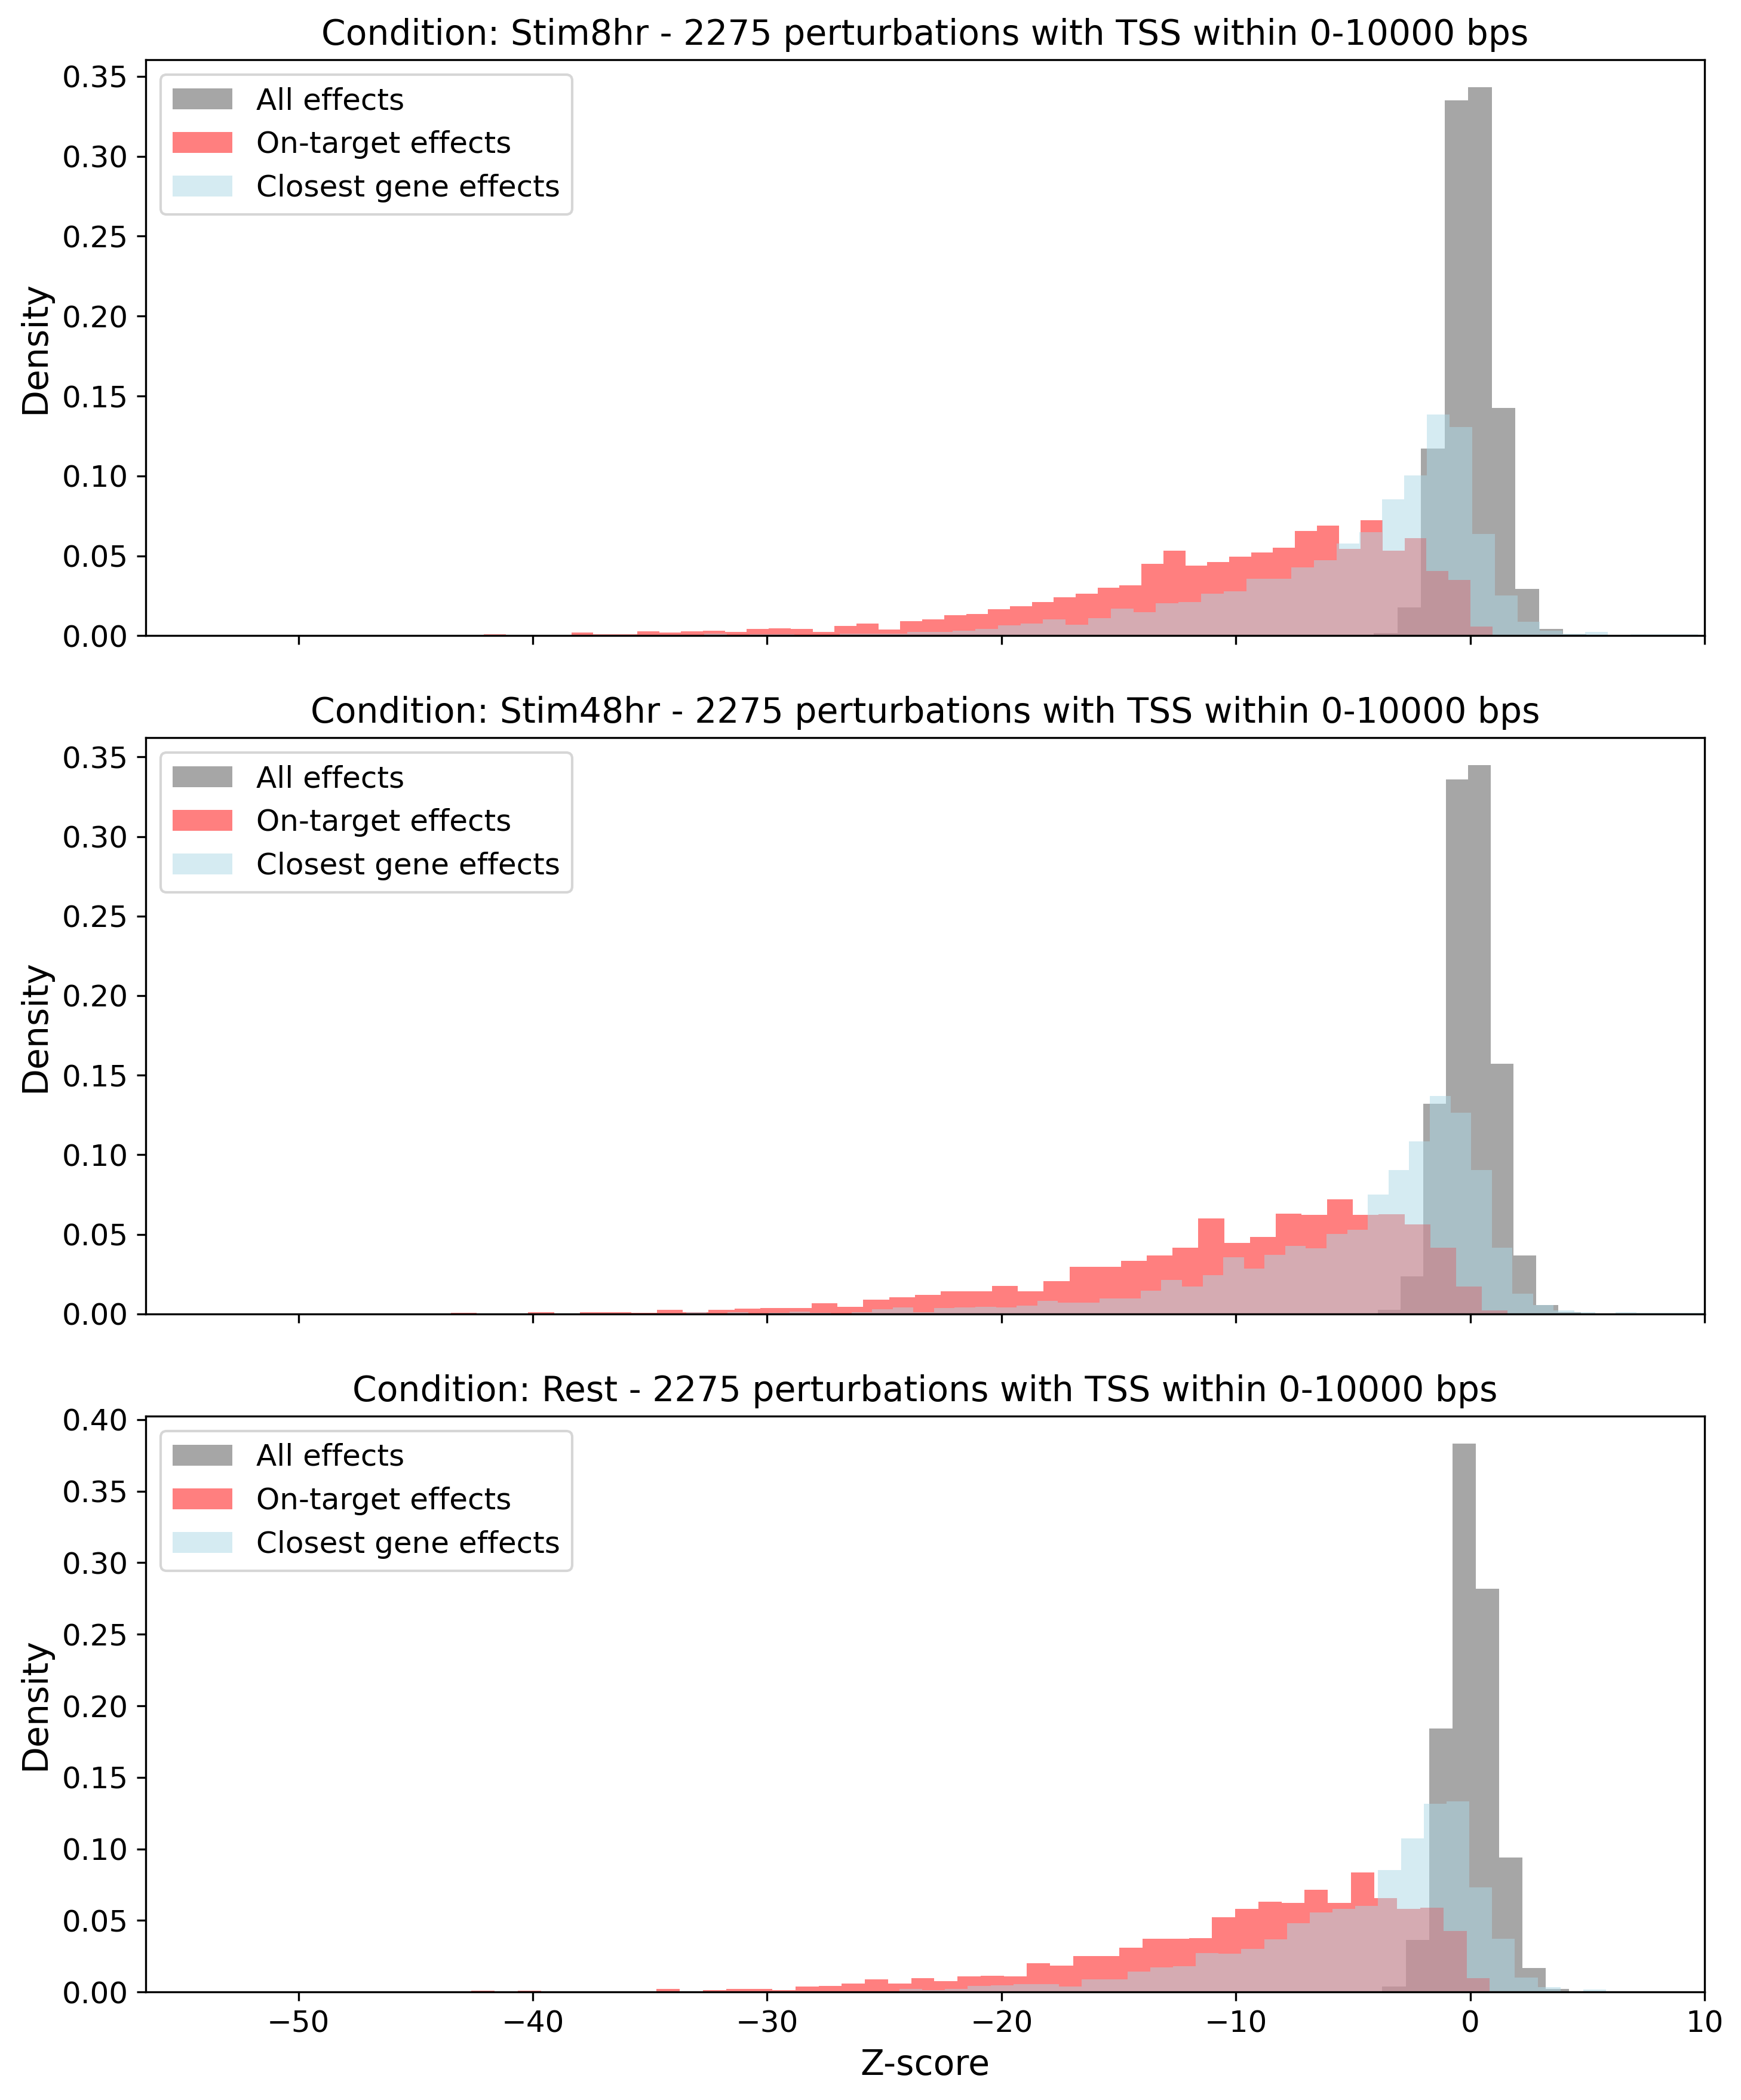

In [73]:
# Get all unique culture conditions
conditions = adata_de.obs['culture_condition'].unique()

min_dist = 0
max_dist = 10000
# Keep targets where the closest gene is between 10kb and 30kb away
keep_targets = all_ontarget_effect[all_ontarget_effect['rank'] == 1][
    (all_ontarget_effect[all_ontarget_effect['rank'] == 1].distance >= min_dist) & 
    (all_ontarget_effect[all_ontarget_effect['rank'] == 1].distance < max_dist)
].target_contrast.unique()
pl_df = all_ontarget_effect[all_ontarget_effect.target_contrast.isin(keep_targets)]
n_perts = pl_df.target_contrast.nunique()
# Create a figure with subplots, one for each condition
fig, axes = plt.subplots(len(conditions), 1, figsize=(10, 4*len(conditions)), sharex=True)

for i, cond in enumerate(conditions):
    axes[i].hist(adata_de[adata_de.obs['culture_condition'] == cond].layers['zscore'].flatten(), 
                bins=100, density=True, alpha=0.7, color='grey', label='All effects')
    # axes[i].hist(all_ontarget_effect[(all_ontarget_effect['rank'] == 0) & (all_ontarget_effect.culture_condition==cond)]['zscore'], bins=50, density=True, alpha=0.7, 
    #             color='red', label='On-target effects')
    axes[i].hist(pl_df[(pl_df['rank'] == 0) & (pl_df.culture_condition==cond)]['zscore'], bins=50, density=True, alpha=0.5, 
                color='red', label='On-target effects');
    axes[i].hist(pl_df[(pl_df['rank'] == 1) & (pl_df.culture_condition==cond)]['zscore'], bins=50, density=True, alpha=0.5, 
                color='lightblue', label=f'Closest gene effects')
    
    axes[i].set_ylabel('Density', fontsize=14)
    axes[i].tick_params(labelsize=12)
    axes[i].legend(fontsize=12)
    axes[i].set_title(f'Condition: {cond} - {n_perts} perturbations with TSS within {min_dist}-{max_dist} bps', fontsize=14)
    axes[i].set_xlim(right=10)  # Set upper x-limit to 10

# Set common x-label
plt.xlabel('Z-score', fontsize=14)
plt.tight_layout()

In [75]:
closest_gene_effect = all_ontarget_effect[all_ontarget_effect['rank'] == 1]
closest_gene_effect['distance_bins'] = pd.cut(
    closest_gene_effect['distance'],
    bins=[0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, float('inf')],
    labels=['0-5kb', '5-10kb', '10-15kb', '15-20kb', '20-25kb', '25-30kb', '30-35kb', '35-40kb', '40-45kb', '45-50kb', '>50kb']
)
closest_gene_effect = pd.concat([closest_gene_effect, all_ontarget_effect[all_ontarget_effect['rank'] == 0]])
closest_gene_effect['distance_bins'] = np.where(closest_gene_effect['rank'] == 0, 'on-target', closest_gene_effect['distance_bins'])
distance_bin_order = ['on-target', '0-5kb', '5-10kb', '10-15kb', '15-20kb', '20-25kb', '25-30kb', '30-35kb', '35-40kb', '40-45kb', '45-50kb', '>50kb']
closest_gene_effect['distance_bins'] = pd.Categorical(
    closest_gene_effect['distance_bins'], 
    categories=distance_bin_order,
    ordered=True
)
closest_gene_effect['gene_class'] = np.where(closest_gene_effect['distance_bins'] == 'on-target', 'target gene', 'closest TSS gene')
closest_gene_effect = closest_gene_effect.reset_index()

# Get mean and iqr across all genes
mean_zscore = np.median(adata_de.layers['zscore'].flatten())
iqr_zscore = np.percentile(adata_de.layers['zscore'].flatten(), 75) - np.percentile(adata_de.layers['zscore'].flatten(), 25)


/tmp/ipykernel_1370790/2981234628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closest_gene_effect['distance_bins'] = pd.cut(


In [76]:
closest_gene_effect.value_counts('culture_condition')

culture_condition
Stim8hr     15390
Rest        15239
Stim48hr    15227
Name: count, dtype: int64

/tmp/ipykernel_1370790/662485476.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_all = unique_targets.groupby(['distance_bins', 'gene_class']).size().unstack()
/tmp/ipykernel_1370790/662485476.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


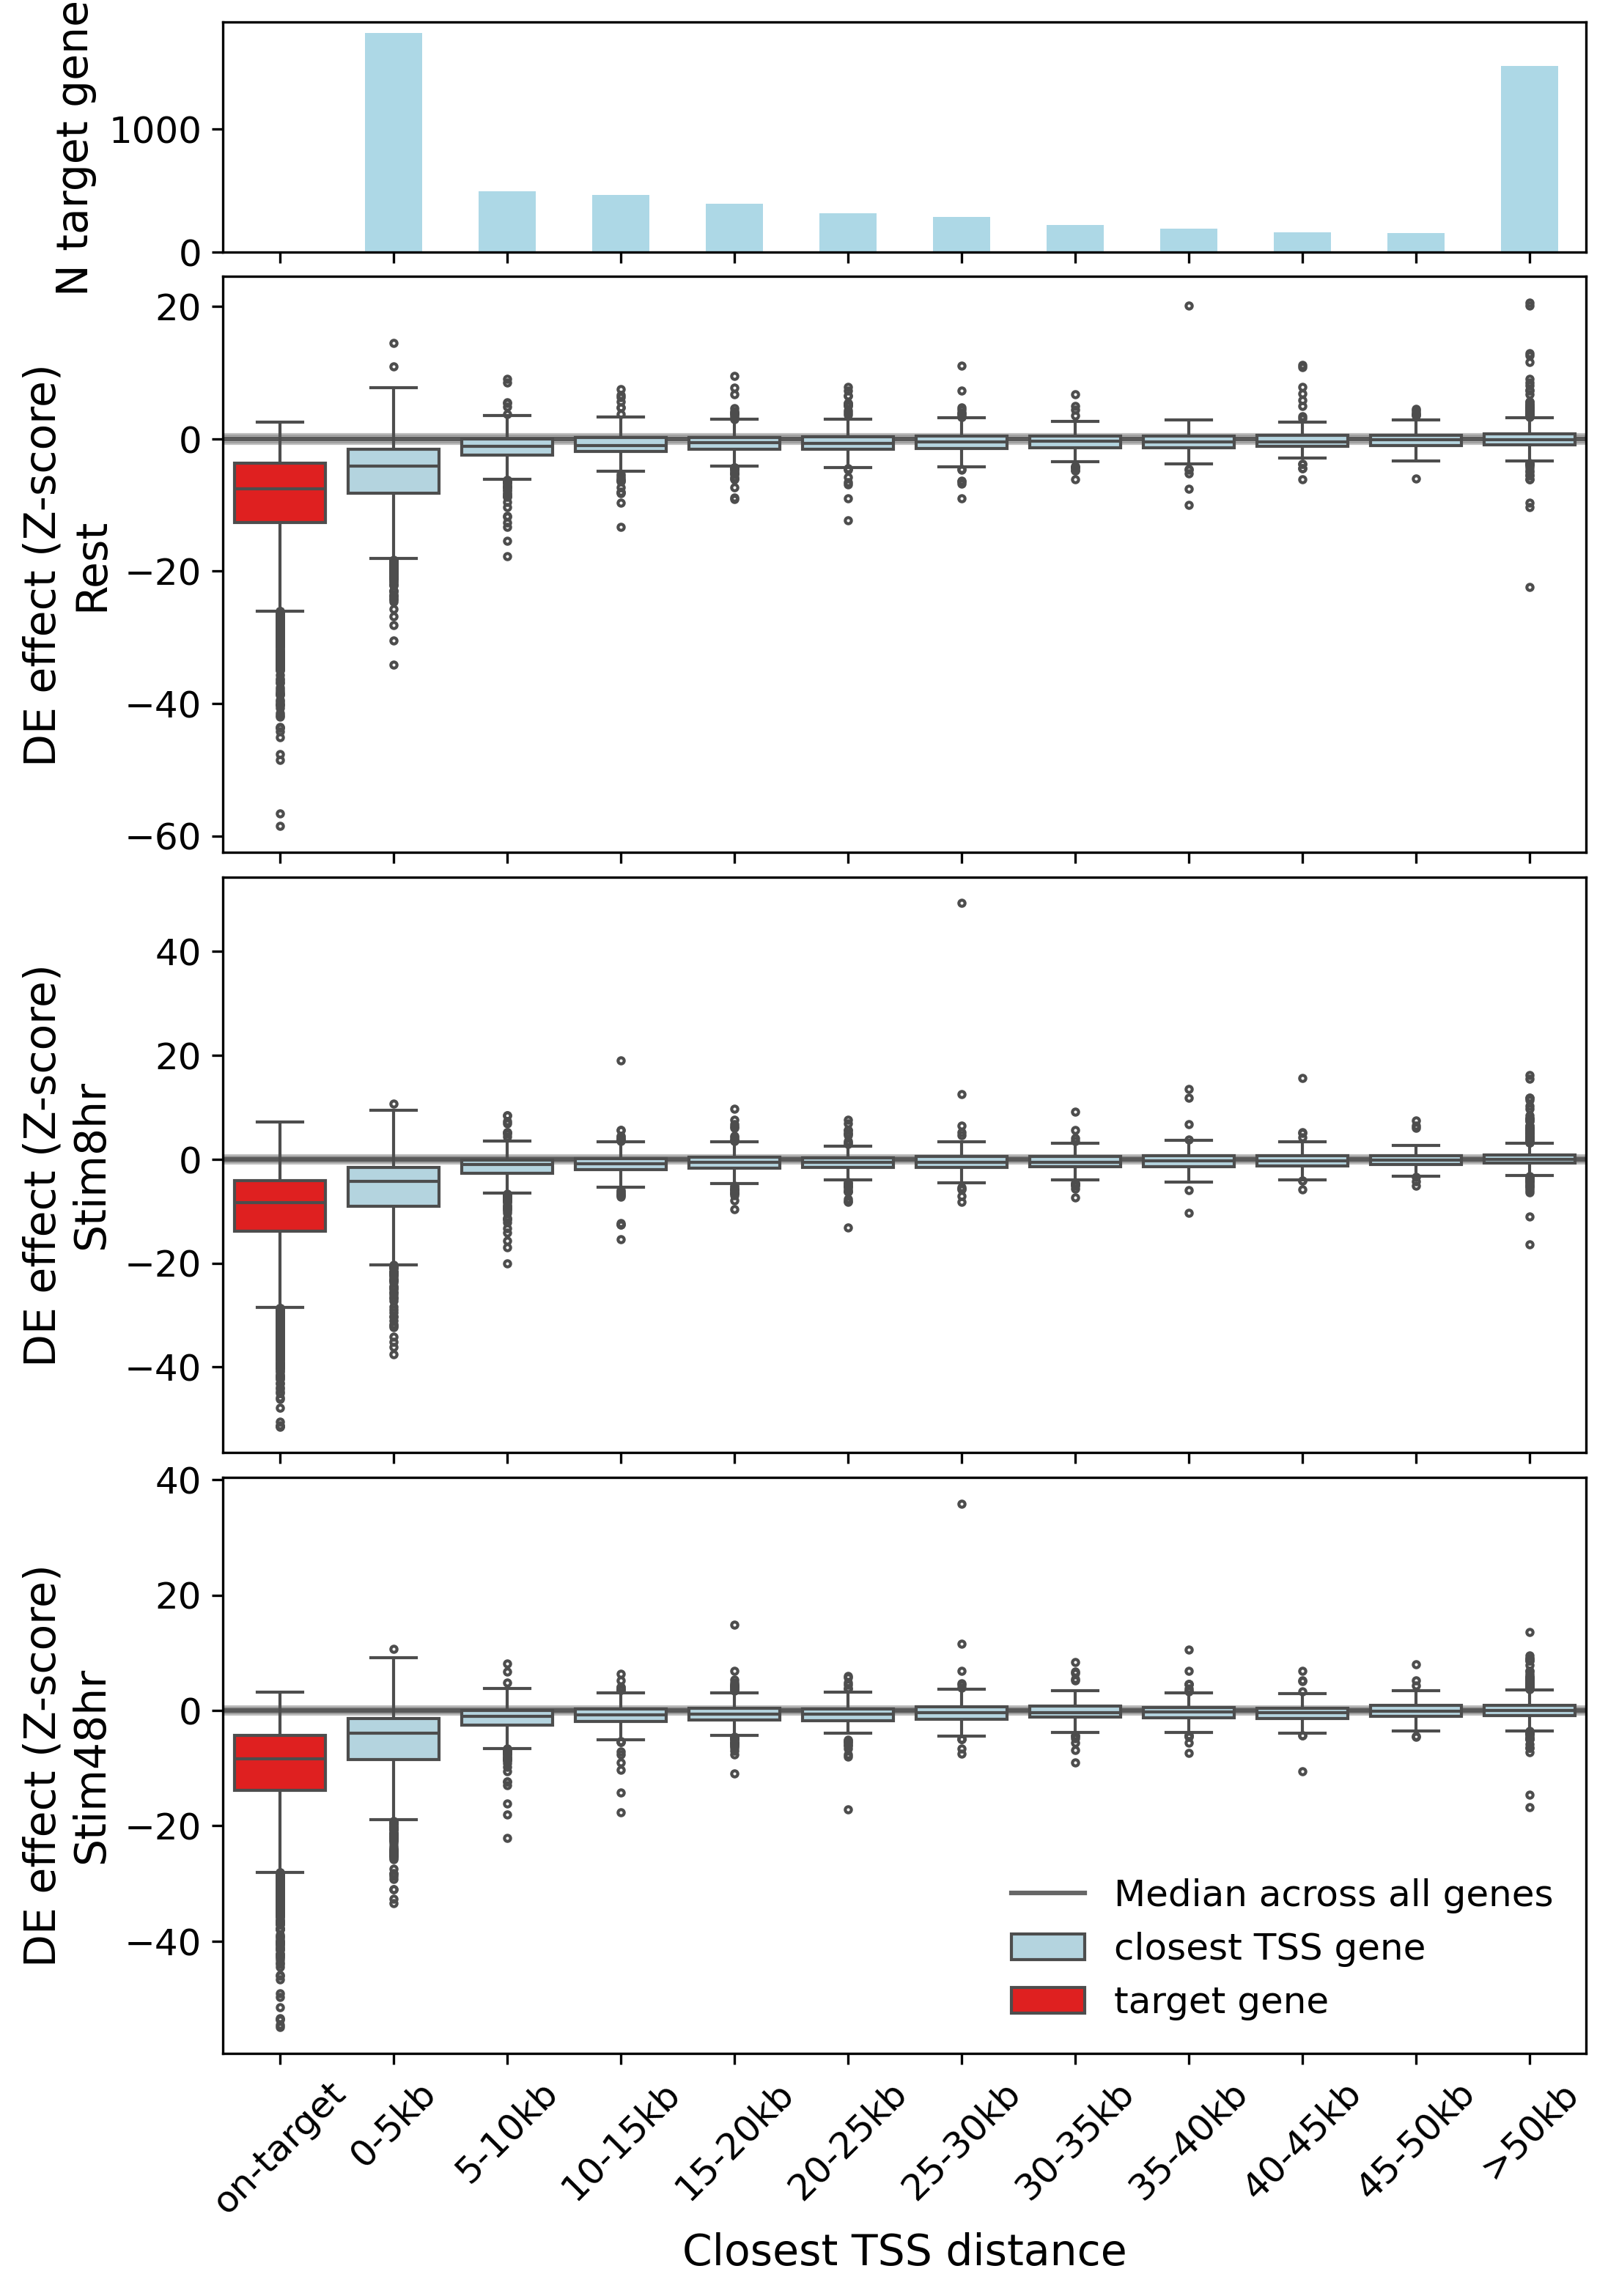

In [77]:
conditions = ['Rest', 'Stim8hr', 'Stim48hr']

# Create figure with 4 rows (1 for barplot, 3 for boxplots) and 1 column
fig, axes = plt.subplots(4, 1, figsize=(8, 12), 
                        height_ratios=[0.4, 1, 1, 1], gridspec_kw={'hspace': 0.05}, sharex=True)

# Set font sizes
title_fontsize = 16
label_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12

# Plot barplot in first row showing unique target gene counts
unique_targets = closest_gene_effect[['target_contrast', 'distance_bins', 'gene_class']].drop_duplicates()
counts_all = unique_targets.groupby(['distance_bins', 'gene_class']).size().unstack()
counts_all['closest TSS gene'].plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_ylabel('N target genes', fontsize=label_fontsize)
axes[0].set_xlabel('', fontsize=label_fontsize)
axes[0].tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
axes[0].tick_params(axis='y', labelsize=tick_fontsize)

# Plot boxplots for each condition in subsequent rows
for i, c in enumerate(conditions, start=1):
    # Median across genes
    axes[i].axhline(y=mean_zscore, color='#404040', linestyle='-', alpha=0.8, label='Median across all genes')
    axes[i].axhspan(mean_zscore - iqr_zscore/2, mean_zscore + iqr_zscore/2, 
                color='grey', alpha=0.5)
                
    sns.boxplot(
        data=closest_gene_effect[closest_gene_effect['culture_condition'] == c], 
        x='distance_bins', 
        y='zscore',
        hue='gene_class',
        fliersize=2,  # Small black dots for outliers
        palette={'target gene': 'red', 'closest TSS gene': 'lightblue'},  # Custom color palette
        ax=axes[i]
    )

    axes[i].set_ylabel(f'DE effect (Z-score)\n{c}', fontsize=label_fontsize)
    axes[i].set_xlabel('Closest TSS distance', fontsize=label_fontsize)
    axes[i].tick_params(axis='x', rotation=45, labelsize=tick_fontsize)
    axes[i].tick_params(axis='y', labelsize=tick_fontsize)
    
    # Only show legend for last subplot
    if i < len(conditions):
        axes[i].get_legend().remove()
    else:
        axes[i].legend(fontsize=legend_fontsize, loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig("results/ontarget_vs_offtarget.pdf")
plt.savefig("results/ontarget_vs_offtarget.png")

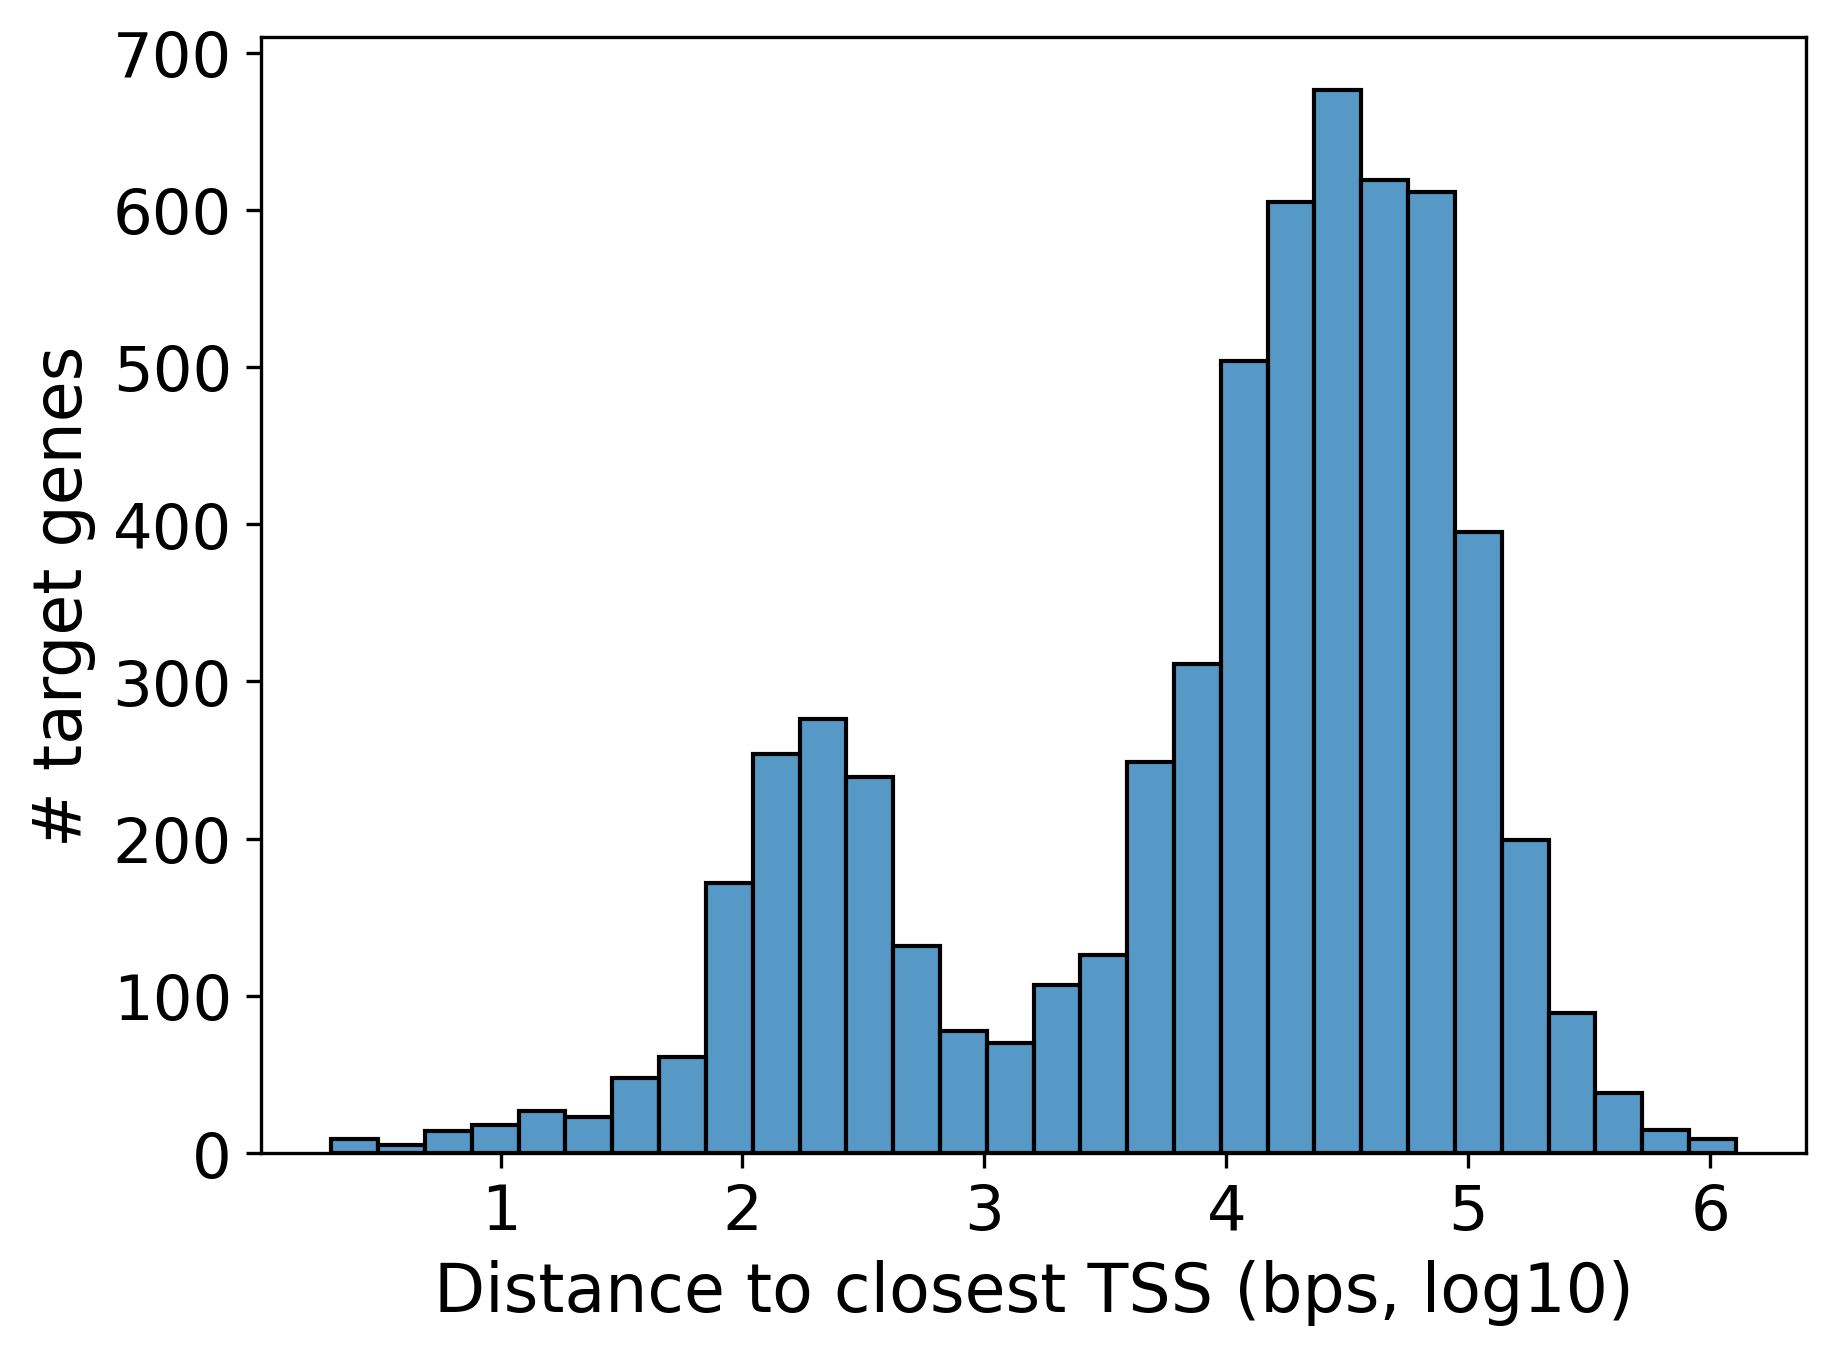

In [78]:
sns.histplot(np.log10(all_ontarget_effect[all_ontarget_effect['rank'] == 1][['target_contrast', 'distance']].drop_duplicates().distance.sort_values()+1), bins=30);
# plt.axvline(np.log10(10000), linestyle=':', color='red');
plt.xlabel('Distance to closest TSS (bps, log10)');
plt.ylabel('# target genes');

In [79]:
n_tested_perturbed_gs = ontarget_df.target_contrast.nunique()
n_perturbed_gs_5kb = all_ontarget_effect[(all_ontarget_effect['rank'] == 1) & (all_ontarget_effect['distance'] <= 5000)].target_contrast.nunique()
print(f'{n_perturbed_gs_5kb}/{n_tested_perturbed_gs} within 5kb TSS ({(n_perturbed_gs_5kb/n_tested_perturbed_gs)*100})')

1782/9498 within 5kb TSS (18.76184459886292)


In [80]:
# How many significant effects for genes within 5kb?
all_ontarget_effect[(all_ontarget_effect['rank'] == 1) & (all_ontarget_effect['distance'] <= 5000)]\
    .groupby('target_contrast')['significant'].max().value_counts()

significant
1.0    1061
0.0     721
Name: count, dtype: int64

In [81]:
n_tested_perturbed_gs = ontarget_df.target_contrast.nunique()
n_perturbed_gs_10kb = all_ontarget_effect[(all_ontarget_effect['rank'] == 1) & ((all_ontarget_effect['distance'] > 5000) & (all_ontarget_effect['distance'] <= 10000))].target_contrast.nunique()
print(f'{n_perturbed_gs_10kb}/{n_tested_perturbed_gs} within 10kb TSS ({(n_perturbed_gs_10kb/n_tested_perturbed_gs)*100})')

493/9498 within 10kb TSS (5.1905664350389555)


In [82]:
# How many significant effects for genes within 5kb?
all_ontarget_effect[(all_ontarget_effect['rank'] == 1) & ((all_ontarget_effect['distance'] > 5000) & (all_ontarget_effect['distance'] <= 10000))]\
    .groupby('target_contrast')['significant'].max().value_counts()

significant
0.0    371
1.0    122
Name: count, dtype: int64

In [95]:
dist_thresh = 5000
effect_thresh = -1
all_ontarget_effect['adj_p_value'] = all_ontarget_effect['adj_p_value'].fillna(1)
keep_targets = all_ontarget_effect[all_ontarget_effect['rank'] == 1][all_ontarget_effect[all_ontarget_effect['rank'] == 1].distance < dist_thresh].target_contrast.unique()
pl_df = all_ontarget_effect[all_ontarget_effect.target_contrast.isin(keep_targets)]
heatmap_data = pl_df.pivot_table(
    values='zscore', 
    index=['target_contrast', 'culture_condition'], 
    columns='rank'
)
signif_heatmap_data = pl_df.pivot_table(
    values='adj_p_value', 
    index=['target_contrast', 'culture_condition'], 
    columns='rank'
)

# Get cases with significant KD of close gene
putative_offtarget_mask = (heatmap_data[1] < effect_thresh) & (signif_heatmap_data[1] < 0.1) #& (heatmap_data[0] > (1.5*heatmap_data[1])) 
putative_offtarget_mask = putative_offtarget_mask.reset_index().rename({1:'putative_offtarget'}, axis=1)
# suspect_mask = suspect_mask.reset_index().groupby('target_contrast')[1].any()
# suspects = pl_df[pl_df.target_contrast.isin(suspect_mask[suspect_mask].index)].target_contrast.dropna().unique().tolist()

In [96]:
putative_ontarget_mask = (heatmap_data[0] < effect_thresh) & (signif_heatmap_data[0] < 0.1) #& (heatmap_data[0] > (1.5*heatmap_data[1])) 
putative_ontarget_mask = putative_ontarget_mask.reset_index().rename({0:'putative_ontarget'}, axis=1)

df = pd.merge(putative_ontarget_mask, putative_offtarget_mask, on=['target_contrast', 'culture_condition'], how='outer')
df

,target_contrast,culture_condition,putative_ontarget,putative_offtarget
0,ENSG00000000419,Rest,True,True
1,ENSG00000000419,Stim48hr,True,True
2,ENSG00000000419,Stim8hr,True,True
3,ENSG00000000460,Rest,True,True
4,ENSG00000000460,Stim48hr,True,True
...,...,...,...,...
5259,ENSG00000284194,Stim48hr,False,True
5260,ENSG00000284194,Stim8hr,True,True
5261,ENSG00000288722,Rest,False,False
5262,ENSG00000288722,Stim48hr,False,True


In [97]:
putative_offtarget_mask[putative_offtarget_mask['putative_offtarget']].groupby('culture_condition')['putative_offtarget'].sum()

culture_condition
Rest        874
Stim48hr    833
Stim8hr     912
Name: putative_offtarget, dtype: int64

In [98]:
tot_offtarget = df.groupby('target_contrast')['putative_offtarget'].sum() 
tot_ontarget = df.groupby('target_contrast')['putative_ontarget'].sum()
# IF offtarget is detected only in some condition, but ontarget is detected in the same condition, then it's not a putative offtarget
sum(tot_offtarget >= tot_ontarget)

961

In [99]:
putative_offtarget_mask[putative_offtarget_mask['putative_offtarget']].target_contrast.nunique()

1045

In [100]:
print(f"Number of targets with suspect offtargets (at least one condition): {putative_offtarget_mask[putative_offtarget_mask['putative_offtarget']].target_contrast.nunique()}")
print(f"Fraction of all targets: {putative_offtarget_mask[putative_offtarget_mask['putative_offtarget']].target_contrast.nunique()/all_ontarget_effect.target_contrast.nunique():.3f}")

Number of targets with suspect offtargets (at least one condition): 1045
Fraction of all targets: 0.110


## Power and number of cells

In [102]:
de_counts = get_de_stats(adata_de, effect_col='zscore', signif_col='adj_p_value', alpha=0.1)
# Add info on on-target effect
effect_col = 'zscore'
if ontarget_df is not None:
    de_counts = pd.merge(
        de_counts,
        ontarget_df.rename({effect_col:'ontarget_effect_size', 'significant':'ontarget_significant', 'culture_condition':'condition'}, axis=1)[
        ['ontarget_effect_size', 'ontarget_significant', 'target_contrast', 'condition', 'baseMean']
        ],
        how='left'
    )
    de_counts['ontarget_effect_size'] = de_counts['ontarget_effect_size'].fillna(0)

# Add info on off targets
de_counts = pd.merge(de_counts, putative_offtarget_mask.rename({'culture_condition':'condition', 'putative_offtarget':'offtarget_flag'}, axis=1), how='left')
de_counts['offtarget_flag'] = de_counts['offtarget_flag'].fillna(False)

# Consider significant KD where the p-value is NA because of independent filtering, but effect size consistent with KD
de_counts['ontarget_significant'] = np.where(((de_counts['ontarget_significant'].isna()) & (de_counts['n_total_de_genes'] > 0) & (de_counts['ontarget_effect_size'] < 0) & (~de_counts['offtarget_flag'])), 1, de_counts['ontarget_significant'])
de_counts['ontarget_significant'] = de_counts['ontarget_significant'].fillna(0)
de_counts['ontarget_significant'] = de_counts['ontarget_significant'].astype(bool)

assert de_counts.shape[0] == adata_de.n_obs
de_counts.head()

/tmp/ipykernel_1370790/1711992183.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  de_counts['offtarget_flag'] = de_counts['offtarget_flag'].fillna(False)


,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,offtarget_flag
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False


## Number of DE genes per perturbation

In [104]:
df = de_counts[~de_counts.ontarget_significant][['target_name', 'n_total_de_genes']]
sum(df['n_total_de_genes'] > 2)/df['n_total_de_genes'].shape[0]

0.3061496278887583

In [109]:
de_counts.to_csv(f'../../results/{experiment_name}/DE_summary_stats_per_target.csv')
de_counts.to_csv(f'{datadir}/DE_results_all_confounders/DE_summary_stats_per_target.csv')
de_counts.head()

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,offtarget_flag,n_total_genes_category
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False,2-10 DE genes
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False,1 DE gene


In [110]:
f'{datadir}/DE_results_all_confounders/DE_summary_stats_per_target.csv'

'/mnt/oak/users/emma/data/GWT/CD4i_final//DE_results_all_confounders/DE_summary_stats_per_target.csv'

In [6]:
de_counts = pd.read_csv(f'{datadir}/DE_results_all_confounders/DE_summary_stats_per_target.csv', index_col=0)
de_counts.head()

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,offtarget_flag,n_total_genes_category
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False,2-10 DE genes
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False,1 DE gene


In [7]:
ontarget_df = pd.read_csv(f'{datadir}/DE_results_all_confounders/on_target_effects.csv', index_col=0)
ontarget_df.head()

,index,gene,log_fc,zscore,baseMean,adj_p_value,significant,gene_name,culture_condition,target_contrast
0,ENSG00000000419_Rest,ENSG00000000419,-1.703465,-17.612309,89.948299,1.975769e-65,True,DPM1,Rest,ENSG00000000419
9354,ENSG00000000457_Rest,ENSG00000000457,-1.048135,-4.930968,23.079312,1.392359e-03,True,SCYL3,Rest,ENSG00000000457
18708,ENSG00000000460_Rest,ENSG00000000460,-2.294418,-13.726757,53.395050,8.688725e-39,True,C1orf112,Rest,ENSG00000000460
28062,ENSG00000000971_Rest,ENSG00000000971,-1.262355,-1.083118,1.183110,9.999999e-01,False,CFH,Rest,ENSG00000000971
37416,ENSG00000001036_Rest,ENSG00000001036,-3.221094,-7.333048,12.932647,2.782497e-09,True,FUCA2,Rest,ENSG00000001036


In [8]:
print('Proximal off-target rate:')
print(f'{de_counts.target_name.nunique()} / {de_counts[de_counts['offtarget_flag']].target_name.nunique()}')
print(f'{de_counts.target_name.nunique() / de_counts[de_counts['offtarget_flag']].target_name.nunique()}')

Proximal off-target rate:
11527 / 1045
11.030622009569377


In [9]:
de_counts.groupby('target_name')['offtarget_flag'].sum().value_counts()

offtarget_flag
0    10482
3      694
2      186
1      165
Name: count, dtype: int64

In [10]:
de_counts['condition'].value_counts()

condition
Stim8hr     11416
Rest        11288
Stim48hr    11282
Name: count, dtype: int64

In [11]:
## Add distal off-target annotation
distal_offtargets = pd.read_csv('../5_sgRNA_annotation/results/putative_distal_offtarget_hits.csv')
distal_offtargets['distal_offtarget_flag'] = True
distal_offtargets = distal_offtargets[['target', 'culture_condition', 'distal_offtarget_flag']].drop_duplicates()
de_counts = pd.merge(
    de_counts,
    distal_offtargets.rename(columns={'target':'target_name', 'culture_condition':'condition'}),
    how='left'
    )
de_counts['distal_offtarget_flag'] = de_counts['distal_offtarget_flag'].fillna(False)
de_counts = de_counts.rename(columns={'offtarget_flag':'neighboring_gene_KD'})

de_counts['low_target_gex'] = (de_counts['baseMean'] < 1) | (de_counts['baseMean'].isna())


/tmp/ipykernel_1519492/3438805136.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  de_counts['distal_offtarget_flag'] = de_counts['distal_offtarget_flag'].fillna(False)


In [12]:
# Annotate where 1 guide was used 
pbulk_adata = anndata.experimental.read_lazy(f'{datadir}/{experiment_name}_merged.DE_pseudobulk.h5ad')
obs_df = pbulk_adata.obs.to_dataframe()
obs_df[['perturbed_gene_name', 'perturbed_gene_id','culture_condition']] = obs_df[['perturbed_gene_name', 'perturbed_gene_id','culture_condition']].astype(str)
n_guides = obs_df[obs_df['keep_for_DE']].groupby(['perturbed_gene_name', 'perturbed_gene_id','culture_condition'])['guide_id'].nunique().sort_values().reset_index()

de_counts = pd.merge(
    de_counts,
    n_guides.rename(columns={'perturbed_gene_name':'target_name', 'perturbed_gene_id':'target_contrast', 'guide_id':'n_guides', 'culture_condition':'condition'}),
    how='left'
    )

de_counts['single_guide_estimate'] = de_counts['n_guides'] == 1

In [133]:
# # Create categories for number of DE genes with a logical order
# de_counts['n_total_genes_category'] = np.nan
# de_counts['n_total_genes_category'] = np.where(de_counts['n_total_de_genes'] == 0, 'no effect', de_counts['n_total_genes_category'])
# de_counts['n_total_genes_category'] = np.where(de_counts['n_total_de_genes'] == 1, '1 DE gene', de_counts['n_total_genes_category'])
# de_counts['n_total_genes_category'] = np.where((de_counts['n_total_de_genes'] > 1) & (de_counts['n_total_de_genes'] <= 10), '2-10 DE genes', de_counts['n_total_genes_category'])
# de_counts['n_total_genes_category'] = np.where((de_counts['n_total_de_genes'] > 10), '>10 DE genes', de_counts['n_total_genes_category'])

# # Create a categorical type with ordered categories
# category_order = ['no effect', '1 DE gene', '2-10 DE genes', '>10 DE genes']
# de_counts['n_total_genes_category'] = pd.Categorical(
#     de_counts['n_total_genes_category'],
#     categories=category_order,
#     ordered=True
# )

# de_counts['ontarget_effect_category'] = 'on-target KD'
# de_counts['ontarget_effect_category'] = np.where(~de_counts['ontarget_significant'], 'no on-target KD', de_counts['ontarget_effect_category'])
# de_counts['ontarget_effect_category'] = np.where(de_counts['proximal_offtarget_flag'] & (~de_counts['ontarget_significant']), 'putative off-target', de_counts['ontarget_effect_category'])

# # Barplot
# fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharex=True)

# colors = {'on-target KD': '#7570b3', 'no on-target KD': '#d95f02', 'putative off-target':'#1b9e77'}

# # Plot for each condition
# # Get max y value across both conditions to set consistent ylim
# max_y = 0
# for c in ['Rest', 'Stim8hr', 'Stim48hr']:
#     grouped_counts = de_counts[de_counts['condition'] == c].groupby(['n_total_genes_category', 'ontarget_effect_category']).size().reset_index(name='count')
#     grouped_counts = grouped_counts.pivot(index='n_total_genes_category', columns='ontarget_effect_category', values='count').fillna(0)
#     # Reorder columns to match colors dictionary order
#     grouped_counts = grouped_counts[list(colors.keys())]
#     max_y = max(max_y, grouped_counts.sum(axis=1).max())

# for i, c in enumerate(['Rest', 'Stim8hr', 'Stim48hr']):
#     ax = axes[i]
    
#     # Get grouped counts for this condition
#     grouped_counts = de_counts[de_counts['condition'] == c].groupby(['n_total_genes_category', 'ontarget_effect_category']).size().reset_index(name='count')
#     grouped_counts = grouped_counts.pivot(index='n_total_genes_category', columns='ontarget_effect_category', values='count').fillna(0)
#     # Reorder columns to match colors dictionary order
#     grouped_counts = grouped_counts[list(colors.keys())]
    
#     # Create stacked bar plot using colors from dict
#     grouped_counts.plot(kind='bar', color=[colors[col] for col in grouped_counts.columns], stacked=True, ax=ax)
#     ax.set_xlabel('', fontsize=20)
#     if i == 0:
#         ax.set_ylabel('# perturbed genes', fontsize=20)
#         ax.set_title(c, fontsize=20, pad=20)
#     else:
#         ax.set_ylabel('')
#         ax.set_title(c, fontsize=20, pad=20)
#         ax.set_yticklabels([])
    
#     # Set consistent y limits
#     ax.set_ylim(0, max_y + 300)  # Add some padding for labels

#     if i != 2:
#         ax.get_legend().remove()
#     else:
#         ax.legend(title='Perturbation type', frameon=False, fontsize=18, title_fontsize=20, 
#                  bbox_to_anchor=(1.05, 1), loc='upper left')
#     # Add count labels on top of each bar
#     for i, total in enumerate(grouped_counts.sum(axis=1)):
#         ax.text(i, total + 50, str(int(total)), ha='center', fontsize=18)
    
#     # Increase tick label sizes
#     ax.tick_params(axis='both', which='major', labelsize=18)

# plt.tight_layout()
# # plt.savefig("results/N_de_genes_barplot.png")
# # plt.savefig("results/N_de_genes_barplot.pdf")

/tmp/ipykernel_1519492/4141471115.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = de_counts[de_counts['condition'] == c].groupby('n_total_genes_category').size()
/tmp/ipykernel_1519492/4141471115.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = de_counts[de_counts['condition'] == c].groupby('n_total_genes_category').size()
/tmp/ipykernel_1519492/4141471115.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

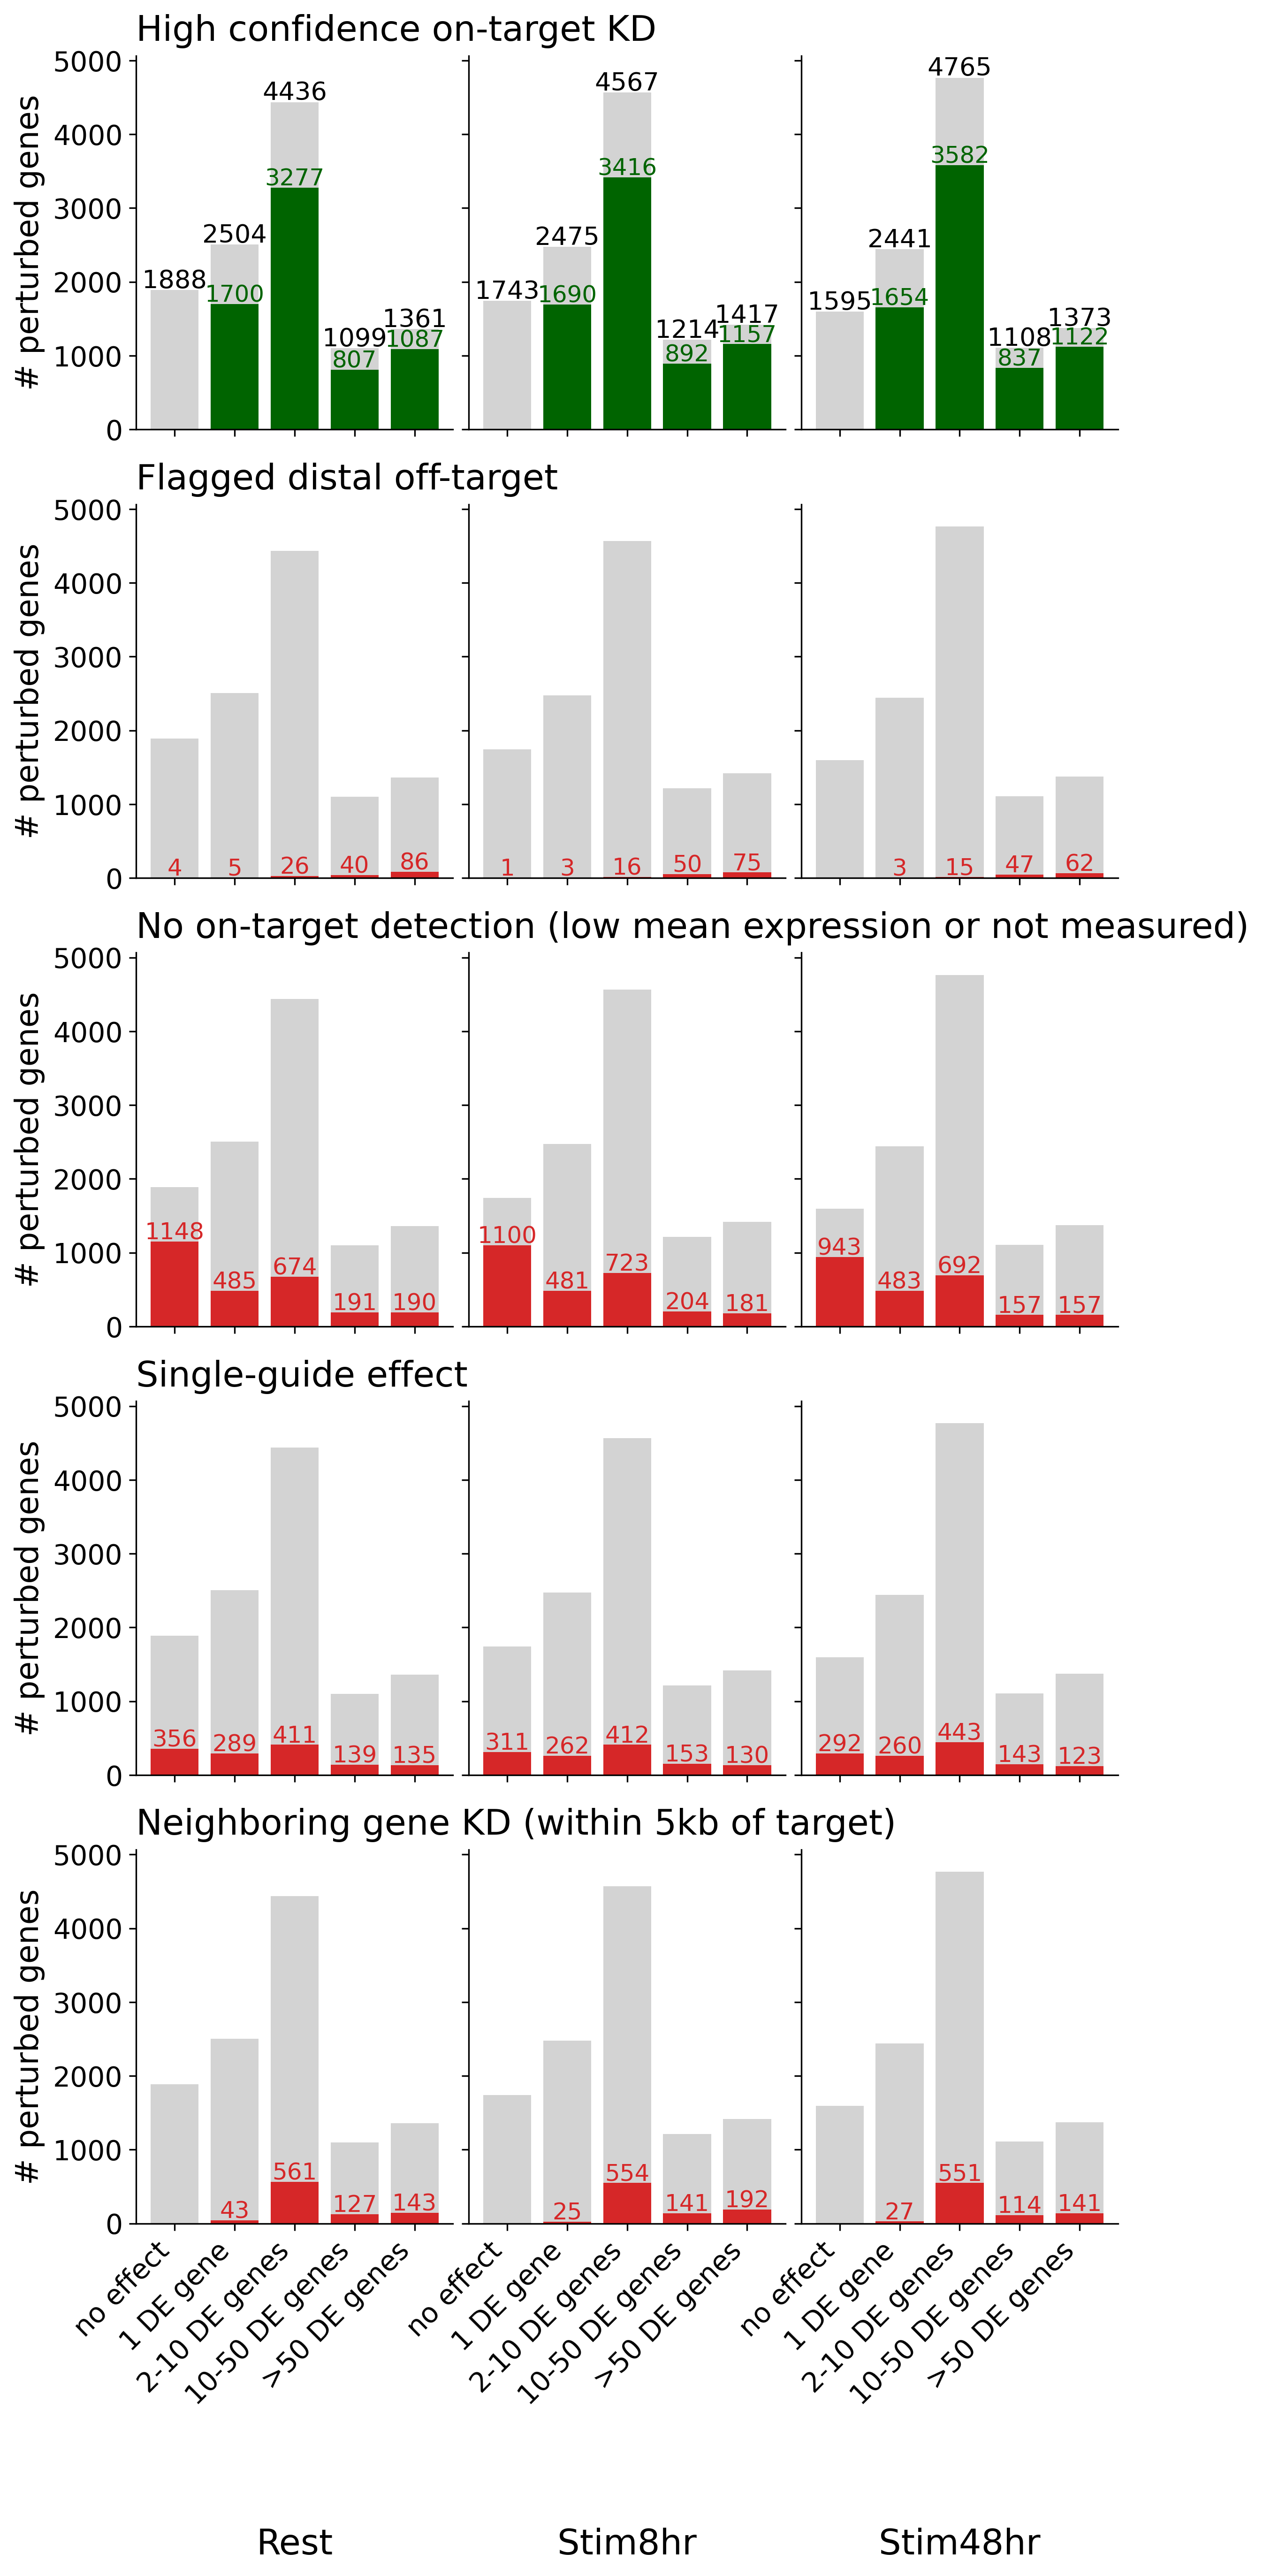

In [13]:
# Create categories for number of DE genes with a logical order
de_counts['n_total_genes_category'] = np.nan
de_counts['n_total_genes_category'] = np.where(de_counts['n_total_de_genes'] == 0, 'no effect', de_counts['n_total_genes_category'])
de_counts['n_total_genes_category'] = np.where(de_counts['n_total_de_genes'] == 1, '1 DE gene', de_counts['n_total_genes_category'])
de_counts['n_total_genes_category'] = np.where((de_counts['n_total_de_genes'] > 1) & (de_counts['n_total_de_genes'] <= 10), '2-10 DE genes', de_counts['n_total_genes_category'])
de_counts['n_total_genes_category'] = np.where((de_counts['n_total_de_genes'] > 10) & (de_counts['n_total_de_genes'] <= 50), '10-50 DE genes', de_counts['n_total_genes_category'])
de_counts['n_total_genes_category'] = np.where((de_counts['n_total_de_genes'] > 50), '>50 DE genes', de_counts['n_total_genes_category'])

# Create a categorical type with ordered categories
category_order = ['no effect', '1 DE gene', '2-10 DE genes', '10-50 DE genes', '>50 DE genes']
de_counts['n_total_genes_category'] = pd.Categorical(
    de_counts['n_total_genes_category'],
    categories=category_order,
    ordered=True
)

comparisons = [
    ('ontarget_significant', 'High confidence on-target KD', '#006400'),
    ('distal_offtarget_flag', 'Flagged distal off-target', '#d62728'),
    ('low_target_gex', 'No on-target detection (low mean expression or not measured)', '#d62728'),
    ('single_guide_estimate', 'Single-guide effect', '#d62728'),
    ('neighboring_gene_KD', 'Neighboring gene KD (within 5kb of target)', '#d62728'),    
]

conditions = ['Rest', 'Stim8hr', 'Stim48hr']
n_rows = len(comparisons)
n_cols = len(conditions)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 4 * n_rows), sharex=True)
plt.subplots_adjust(wspace=0.05)

# Precompute max_y across all conditions
max_y = 0
for c in conditions:
    total = de_counts[de_counts['condition'] == c].groupby('n_total_genes_category').size()
    max_y = max(max_y, total.max())

x = np.arange(len(category_order))

for row, (column, label, color) in enumerate(comparisons):
    for col, c in enumerate(conditions):
        ax = axes[row, col]
        cond_data = de_counts[de_counts['condition'] == c]

        total_counts = cond_data.groupby('n_total_genes_category').size().reindex(category_order, fill_value=0)
        highlight_counts = cond_data[cond_data[column]].groupby('n_total_genes_category').size().reindex(category_order, fill_value=0)

        ax.bar(x, total_counts, color='lightgrey')
        ax.bar(x, highlight_counts, color=color)

        ax.set_xticks(x)
        ax.set_ylim(0, max_y + 300)
        ax.tick_params(axis='both', which='major', labelsize=14)

        # Condition label as x-axis label on last row only
        if row == n_rows - 1:
            ax.set_xticklabels(category_order, rotation=45, ha='right', fontsize=14)
            ax.set_xlabel(c, fontsize=18, labelpad=60)
        else:
            ax.set_xticklabels([])

        # y-axis label and comparison label only on leftmost column
        if col == 0:
            ax.set_ylabel('# perturbed genes', fontsize=16)
            ax.text(0, 1.02, label, transform=ax.transAxes,
                    fontsize=18, ha='left', va='bottom', color='black')
        else:
            ax.set_yticklabels([])

        # Total count labels only in first row
        if row == 0:
            for j, total in enumerate(total_counts):
                ax.text(j, total + 30, str(int(total)), ha='center', fontsize=13)

        # Highlighted count labels on top of colored bar (only if > 0)
        for j, n in enumerate(highlight_counts):
            if n > 0:
                ax.text(j, n + 30, str(int(n)), ha='center', fontsize=12, color=color)

sns.despine()
plt.tight_layout(w_pad=0.1)
plt.savefig("results/N_de_genes_barplot.png")
plt.savefig("results/N_de_genes_barplot.pdf")

In [136]:
# # Summary barplot: mutually exclusive issue categories per perturbation
# # Hierarchy: distal off-target > low target expression > no on-target KD > proximal off-target > clean
# issue_colors = {
#     'Distal off-target': '#e6194b',
#     'Low target expression': '#f58231',
#     'No on-target KD': '#aaaaaa',
#     'Proximal off-target': '#ffe119',
#     'Single-guide estimate': 'blue',
#     'Best quality perturbations': '#3cb44b',
# }

# def assign_issue_category(row):
#     if row['distal_offtarget_flag']:
#         return 'Distal off-target'
#     elif row['low_target_gex']:
#         return 'Low target expression'
#     elif not row['ontarget_significant']:
#         return 'No on-target KD'
#     elif row['single_guide_estimate']:
#         return 'Single-guide estimate'
#     elif row['proximal_offtarget_flag']:
#         return 'Proximal off-target'
#     else:
#         return 'Best quality perturbations'

# de_counts['issue_category'] = de_counts.apply(assign_issue_category, axis=1)
# de_counts['issue_category'] = pd.Categorical(de_counts['issue_category'], categories=list(issue_colors.keys()), ordered=True)

# fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=False)

# for col, c in enumerate(conditions):
#     ax = axes[col]
#     cond_data = de_counts[de_counts['condition'] == c]

#     grouped = (
#         cond_data.groupby(['n_total_genes_category', 'issue_category'], observed=True)
#         .size()
#         .unstack('issue_category')
#         .reindex(category_order)
#         .reindex(columns=list(issue_colors.keys()))
#         .fillna(0)
#     )

#     totals = grouped.sum(axis=1)
#     bottom = np.zeros(len(grouped))
#     x = np.arange(len(grouped))

#     for issue, color in issue_colors.items():
#         vals = grouped[issue].values
#         is_best = issue == 'Best quality perturbations'
#         ax.bar(x, vals, bottom=bottom, color=color, label=issue,
#                edgecolor='black' if is_best else 'none', linewidth=1.2 if is_best else 0)
#         # Label at center of green bar
#         if is_best:
#             for j, (n, b) in enumerate(zip(vals, bottom)):
#                 if n > 0:
#                     ax.text(j, b + n / 2, str(int(n)), ha='center', va='center', fontsize=11, color='black', fontweight='bold')
#         bottom += vals

#     # Total labels on top of each bar
#     for j, total in enumerate(totals):
#         ax.text(j, total + 10, str(int(total)), ha='center', fontsize=12)

#     ax.set_xticks(x)
#     ax.set_xticklabels(category_order, rotation=45, ha='right', fontsize=13)
#     ax.set_xlabel(c, fontsize=18, labelpad=60)
#     ax.tick_params(axis='both', which='major', labelsize=13)
#     ax.set_ylim(0, totals.max() + 150)

#     if col == 0:
#         ax.set_ylabel('# perturbed genes', fontsize=16)
#     else:
#         ax.set_yticklabels([])

#     if col == 2:
#         ax.legend(title='', frameon=False, fontsize=13, bbox_to_anchor=(1.05, 1), loc='upper left')

# sns.despine()
# plt.tight_layout(w_pad=0.1)
# # plt.savefig("results/N_de_genes_barplot_summary.png")
# # plt.savefig("results/N_de_genes_barplot_summary.pdf")

In [211]:
de_counts[de_counts['n_total_de_genes'] >= 1].shape[0]

28760

In [14]:
de_counts[de_counts['n_total_de_genes'] >= 1][[x[0] for x in comparisons]].value_counts()/de_counts[de_counts['n_total_de_genes'] >= 1].shape[0]

ontarget_significant  distal_offtarget_flag  low_target_gex  single_guide_estimate  neighboring_gene_KD
True                  False                  False           False                  False                  0.598540
False                 False                  True            False                  False                  0.133554
True                  False                  False           False                  True                   0.072844
False                 False                  False           False                  False                  0.070132
True                  False                  False           True                   False                  0.048957
False                 False                  False           True                   False                  0.022462
                                             True            True                   False                  0.019089
True                  True                   False           False                  

In [160]:
for c in ['Rest', 'Stim8hr', 'Stim48hr']:
    c_df = de_counts[(de_counts['n_total_de_genes'] >= 1) & (de_counts.condition == c)]
    print(f'--- {c} ---')
    print(c_df[[x[0] for x in comparisons]].value_counts().head())
    print(f'Total: {c_df.shape[0]}')

--- Rest ---
ontarget_significant  distal_offtarget_flag  low_target_gex  single_guide_estimate  neighboring_gene_KD
True                  False                  False           False                  False                  5518
False                 False                  True            False                  False                  1281
                                             False           False                  False                   684
True                  False                  False           False                  True                    682
                                                             True                   False                   482
Name: count, dtype: int64
Total: 9400
--- Stim8hr ---
ontarget_significant  distal_offtarget_flag  low_target_gex  single_guide_estimate  neighboring_gene_KD
True                  False                  False           False                  False                  5786
False                 False                  True    

In [15]:
de_counts

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes,False,False,2.0,False
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene,False,False,2.0,False
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False,2-10 DE genes,False,True,2.0,False
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes,False,False,2.0,False
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False,1 DE gene,False,True,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33981,ENSG00000198342,ZNF442,Rest,324.0,0,0,0,0.000000,False,NaN,False,no effect,False,True,2.0,False
33982,ENSG00000205572,SERF1B,Rest,44.0,7,24,31,0.000000,False,NaN,False,10-50 DE genes,False,True,1.0,True
33983,ENSG00000221890,NPTXR,Rest,293.0,0,3,3,-1.027171,False,0.798092,False,2-10 DE genes,False,True,2.0,False
33984,ENSG00000236320,SLFN14,Rest,848.0,0,0,0,0.000000,False,NaN,False,no effect,False,True,2.0,False


In [16]:
de_counts.to_csv(f'../../results/{experiment_name}/DE_summary_stats_per_target.csv')
de_counts.to_csv(f'{datadir}/DE_results_all_confounders/DE_summary_stats_per_target.csv')
de_counts.head()

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes,False,False,2.0,False
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene,False,False,2.0,False
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False,2-10 DE genes,False,True,2.0,False
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes,False,False,2.0,False
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False,1 DE gene,False,True,2.0,False


### On-target lfc vs strength of effect

In [162]:
from DE_analysis_utils import *
de_counts[de_counts['ontarget_significant']].head()

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes,False,False,2.0,False
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene,False,False,2.0,False
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes,False,False,2.0,False
6,ENSG00000103479,RBL2,Stim8hr,433.0,4,5,9,-14.150025,True,61.807629,False,2-10 DE genes,False,False,2.0,False
8,ENSG00000105374,NKG7,Stim8hr,504.0,0,5,5,-15.886472,True,175.232706,True,2-10 DE genes,False,False,2.0,False


In [163]:
effect_col = 'log_fc'
if ontarget_df is not None:
    de_counts = pd.merge(
        de_counts,
        ontarget_df.rename({effect_col:'ontarget_effect_size_lfc', 'culture_condition':'condition'}, axis=1)[
        ['ontarget_effect_size_lfc', 'target_contrast', 'condition', 'baseMean']
        ],
        how='left'
    )
    de_counts['ontarget_effect_size_lfc'] = de_counts['ontarget_effect_size_lfc'].fillna(0)


In [164]:
de_counts

,target_contrast,target_name,condition,n_cells_target,n_up_genes,n_down_genes,n_total_de_genes,ontarget_effect_size,ontarget_significant,baseMean,neighboring_gene_KD,n_total_genes_category,distal_offtarget_flag,low_target_gex,n_guides,single_guide_estimate,ontarget_effect_size_lfc
0,ENSG00000012963,UBR7,Stim8hr,491.0,0,2,2,-12.952742,True,43.169196,True,2-10 DE genes,False,False,2.0,False,-2.578284
1,ENSG00000017260,ATP2C1,Stim8hr,469.0,0,1,1,-16.307246,True,102.399025,False,1 DE gene,False,False,2.0,False,-1.598167
2,ENSG00000067606,PRKCZ,Stim8hr,427.0,1,1,2,-1.658755,False,0.965897,False,2-10 DE genes,False,True,2.0,False,-1.968797
3,ENSG00000092929,UNC13D,Stim8hr,830.0,0,2,2,-19.259466,True,60.904483,False,2-10 DE genes,False,False,2.0,False,-3.916285
4,ENSG00000100504,PYGL,Stim8hr,414.0,1,0,1,0.000000,False,NaN,False,1 DE gene,False,True,2.0,False,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33981,ENSG00000198342,ZNF442,Rest,324.0,0,0,0,0.000000,False,NaN,False,no effect,False,True,2.0,False,0.000000
33982,ENSG00000205572,SERF1B,Rest,44.0,7,24,31,0.000000,False,NaN,False,10-50 DE genes,False,True,1.0,True,0.000000
33983,ENSG00000221890,NPTXR,Rest,293.0,0,3,3,-1.027171,False,0.798092,False,2-10 DE genes,False,True,2.0,False,-1.284935
33984,ENSG00000236320,SLFN14,Rest,848.0,0,0,0,0.000000,False,NaN,False,no effect,False,True,2.0,False,0.000000


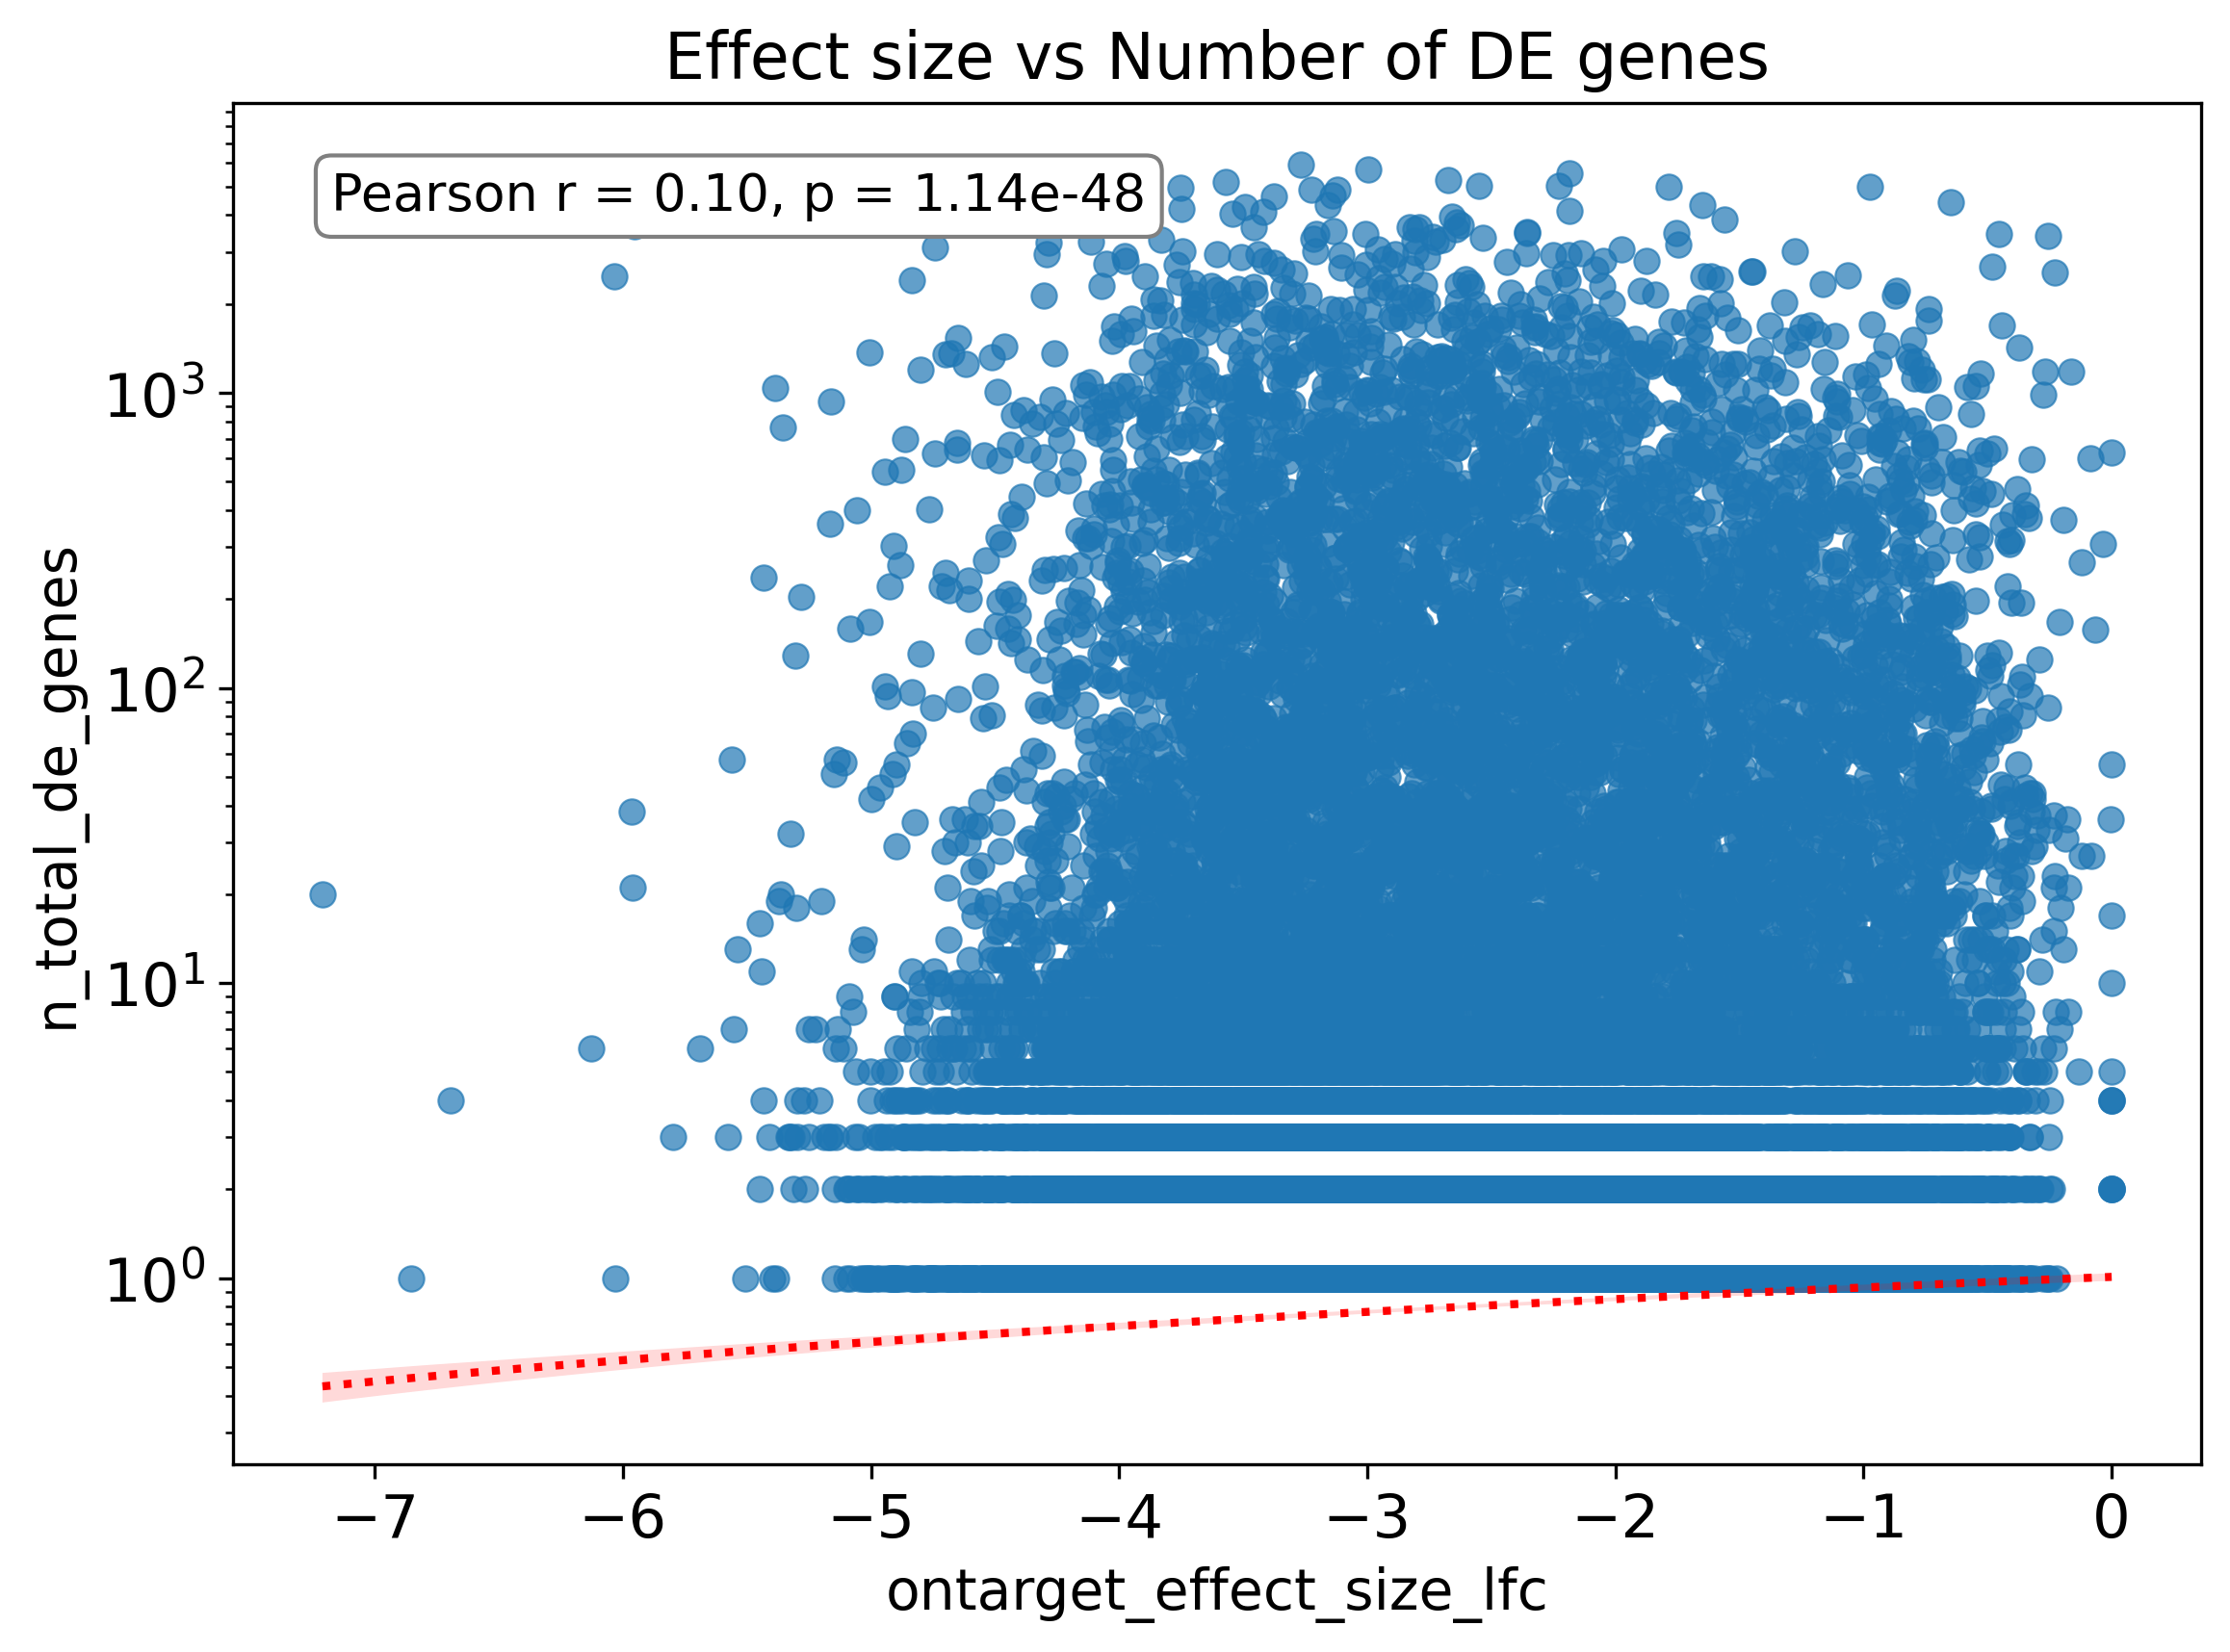

In [165]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(8,6))
scatter = sns.scatterplot(
    data=de_counts[de_counts['ontarget_significant']], x='ontarget_effect_size_lfc', y='n_total_de_genes', 
    ax=ax, alpha=0.7, s=40, edgecolor=None
)
ax.set_yscale('log')
ax.set_xlabel('On-target effect size', fontsize=14)
ax.set_ylabel('Number of DE genes (log scale)', fontsize=14)
ax.set_title('Effect size vs Number of DE genes', fontsize=16)

# Calculate correlation
# (Remove NaN and Inf for correlation calculation)
corr_df = de_counts[de_counts['ontarget_significant']][['ontarget_effect_size_lfc', 'n_total_de_genes']].dropna()

if len(corr_df) > 1:
    r, p = stats.pearsonr(corr_df['ontarget_effect_size_lfc'], np.log10(corr_df['n_total_de_genes']))
    corr_txt = f"Pearson r = {r:.2f}, p = {p:.2e}"
    # Annotate on plot
    ax.annotate(corr_txt, xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=13, ha='left', va='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

# Optionally: add a regression line
sns.regplot(
    data=corr_df, x='ontarget_effect_size_lfc', y=np.log10(corr_df['n_total_de_genes']),
    scatter=False, ax=ax, color='red', line_kws={'lw':2, 'ls':':'}
)

plt.tight_layout()

<Axes: >

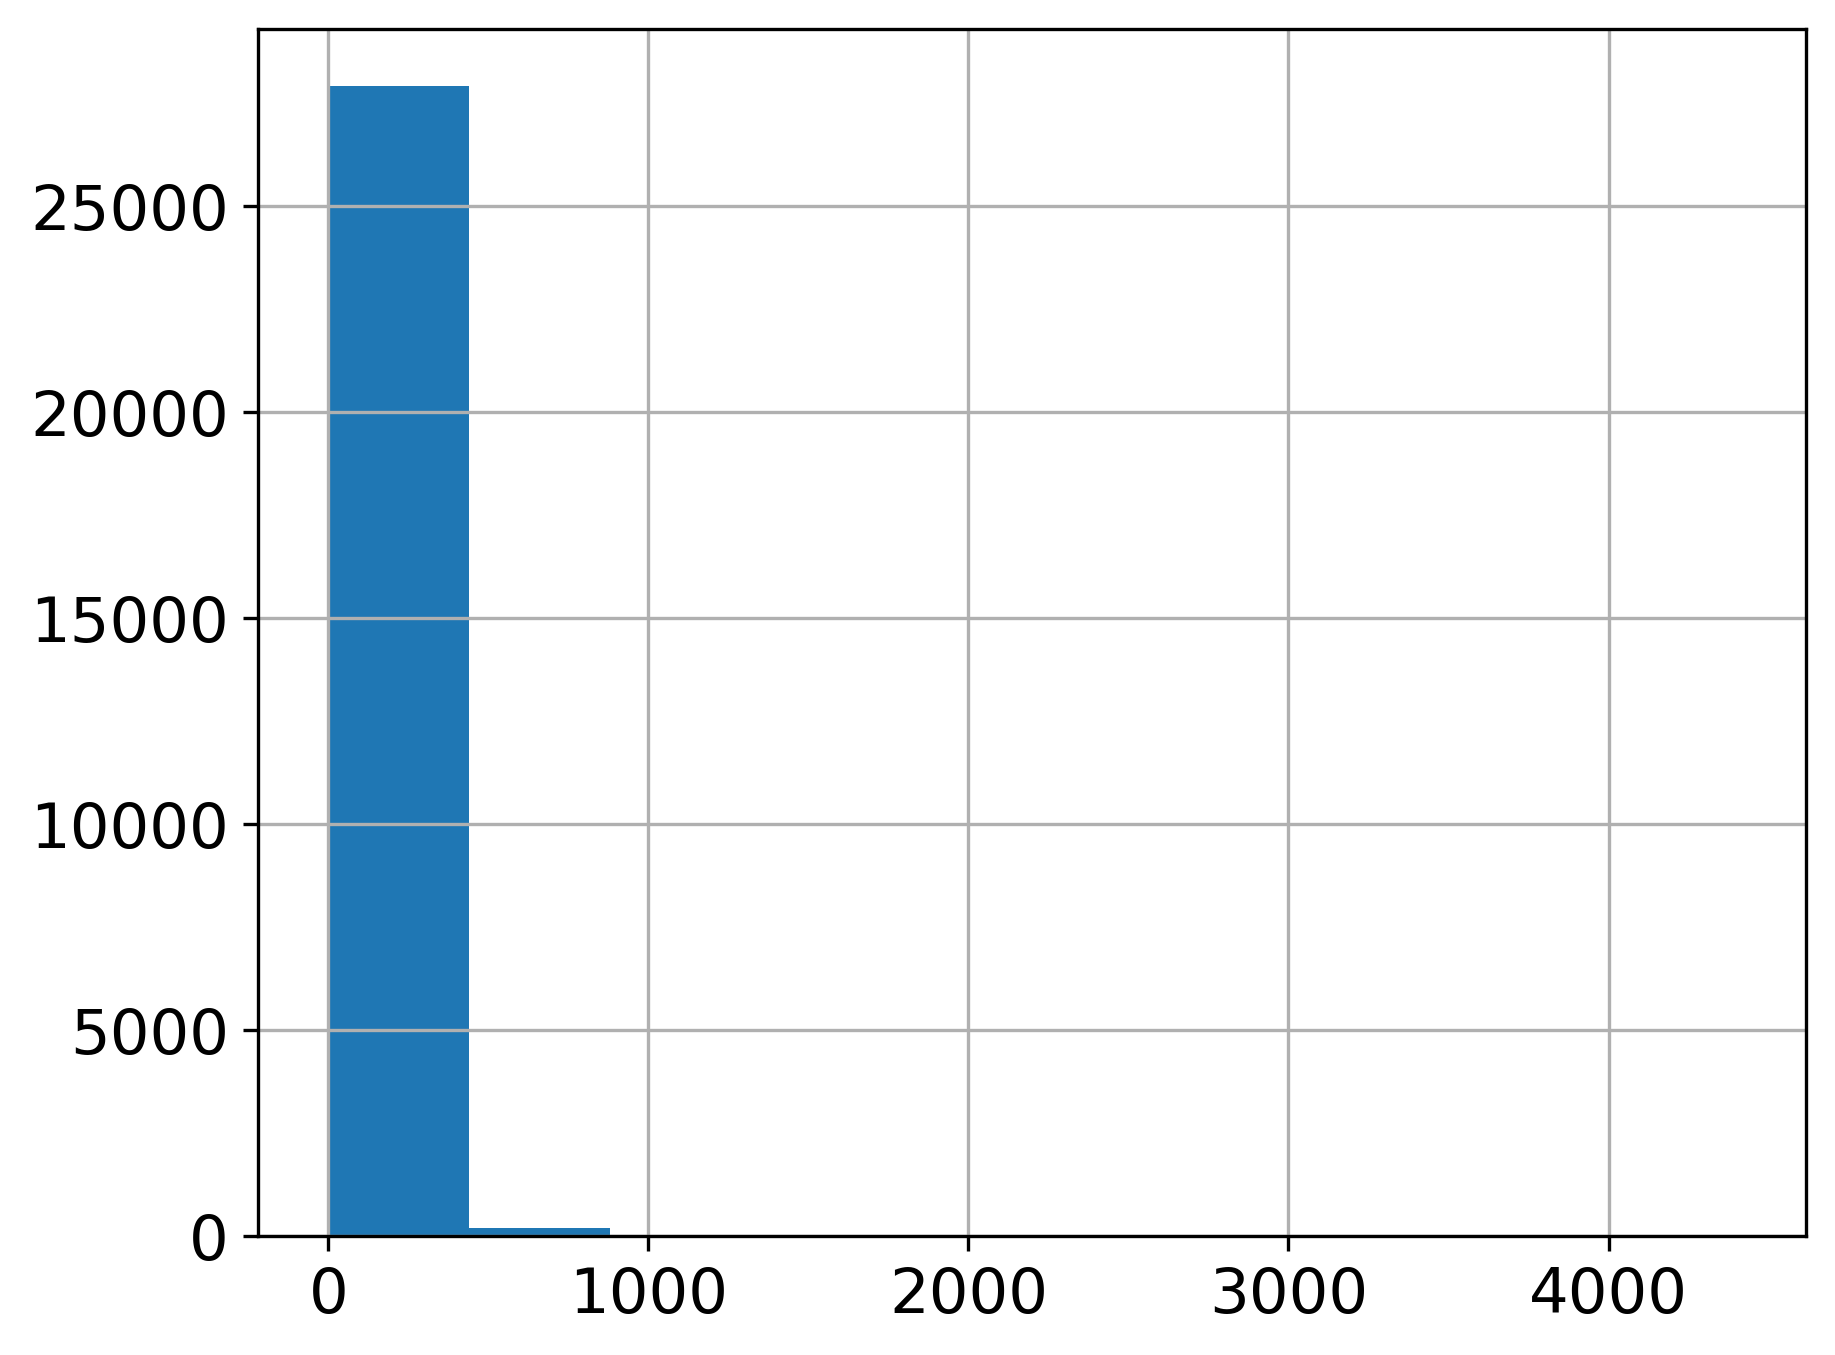

In [83]:
pl_df.baseMean.hist()

/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


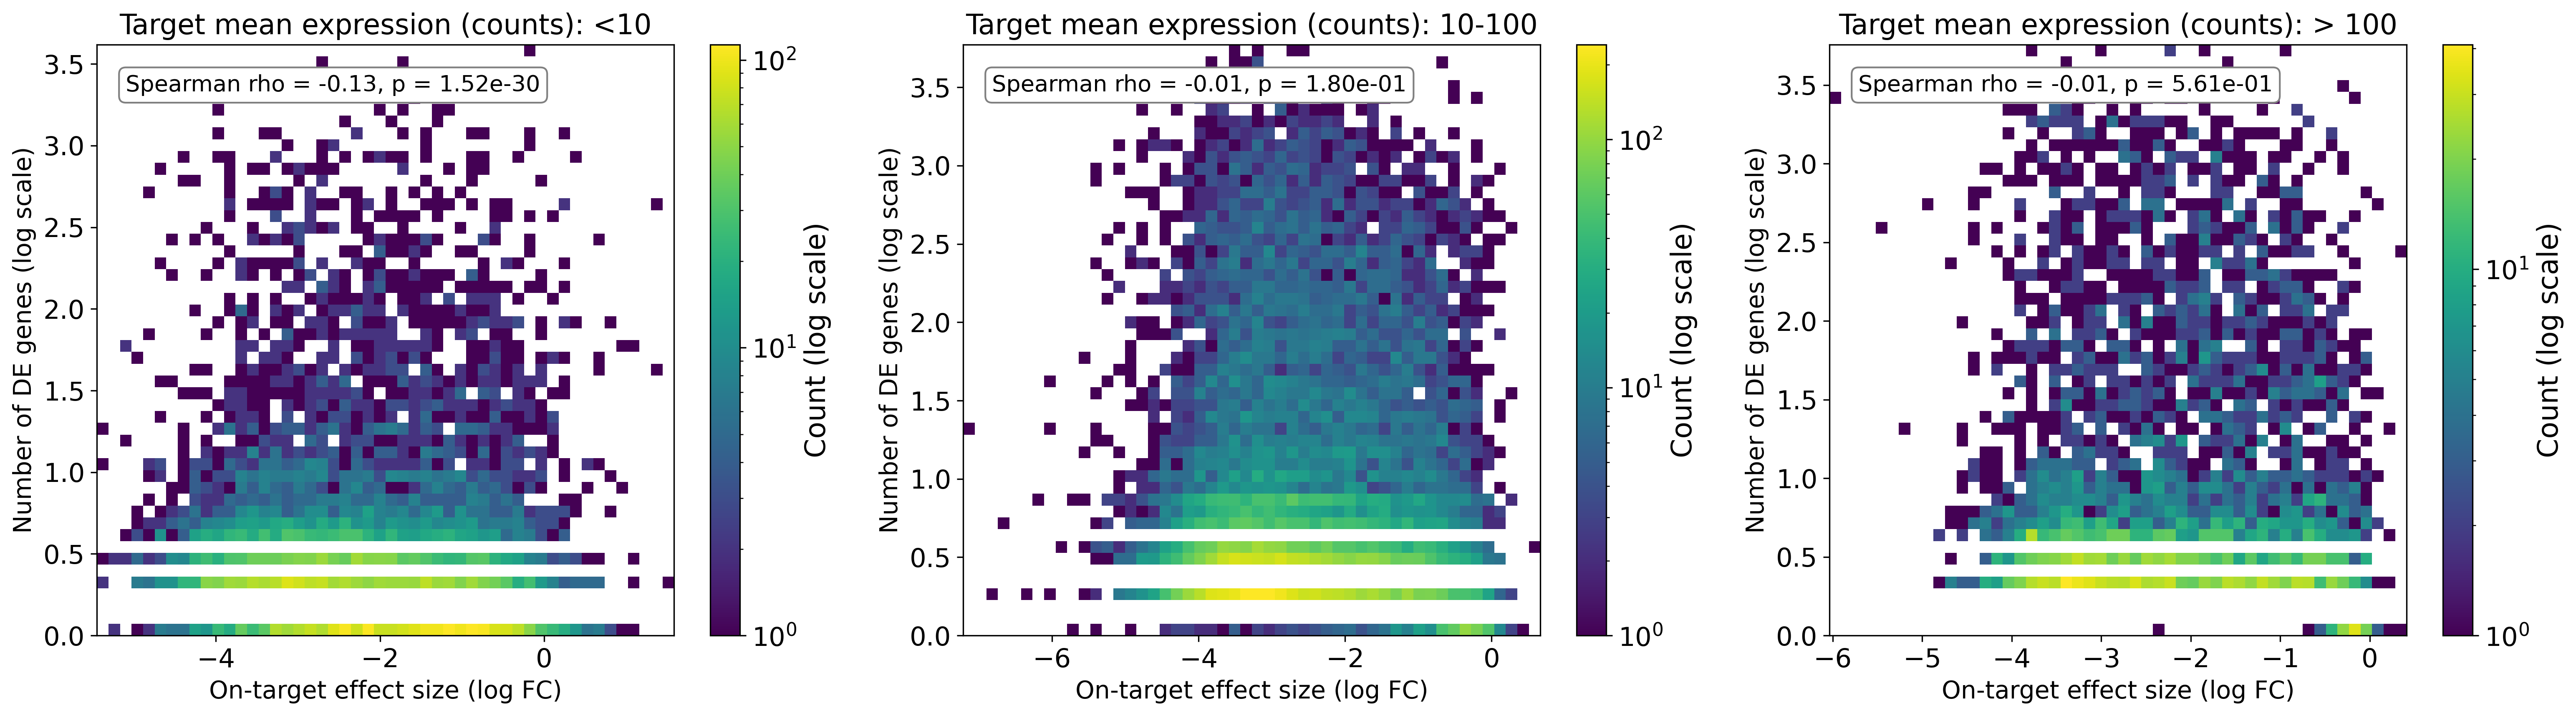

In [167]:
from matplotlib.colors import LogNorm

# Bin baseMean
n_bins = 3  # You can change this to the desired number of bins
pl_df = pd.merge(de_counts.rename(columns={'condition':'culture_condition'}), ontarget_df[['target_contrast', 'culture_condition', 'log_fc', 'adj_p_value']])
# pl_df = pl_df[(pl_df['adj_p_value'] < 0.1) & (pl_df['log_fc'] < 0)].copy()
pl_df = pl_df.copy()
pl_df['baseMean_bin'] = pd.cut(
    np.log10(pl_df['baseMean']), 
    bins=[-np.inf, 1, 2,  np.inf], 
    labels=['<10', '10-100', '> 100']
)

# Set color palette for bins (will use for annotating only)
palette = sns.color_palette("Set2", n_colors=pl_df['baseMean_bin'].nunique())
bin_labels = pl_df['baseMean_bin'].cat.categories

fig, axes = plt.subplots(1, n_bins, figsize=(7*n_bins, 6), sharey=False)
if n_bins == 1:
    axes = [axes]
for i, (b, ax) in enumerate(zip(bin_labels, axes)):
    bin_df = pl_df[(pl_df['baseMean_bin'] == b)]
    x = bin_df['ontarget_effect_size_lfc']
    y = np.log10(bin_df['n_total_de_genes']+1)
    # Remove NaN values
    mask = ~(x.isna() | y.isna())
    x = x[mask]
    y = y[mask]
    # 2D histogram
    h = ax.hist2d(
        x, y, bins=50, norm=LogNorm(), cmap="viridis"
    )
    plt.colorbar(h[3], ax=ax, label='Count (log scale)')

    ax.set_xlabel('On-target effect size (log FC)', fontsize=14)
    ax.set_ylabel('Number of DE genes (log scale)', fontsize=14)
    
    ax.set_title(f'Target mean expression (counts): {b}', fontsize=16)
    corr_df = bin_df[['log_fc', 'n_total_de_genes']].dropna()
    if len(corr_df) > 1:
        r, p = stats.spearmanr(corr_df['log_fc'], np.log10(corr_df['n_total_de_genes']))
        corr_txt = f"Spearman rho = {r:.2f}, p = {p:.2e}"
        ax.annotate(corr_txt, xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=13, ha='left', va='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))
plt.tight_layout()
plt.savefig('./results/ontarget_vs_n_de_genes.pdf')

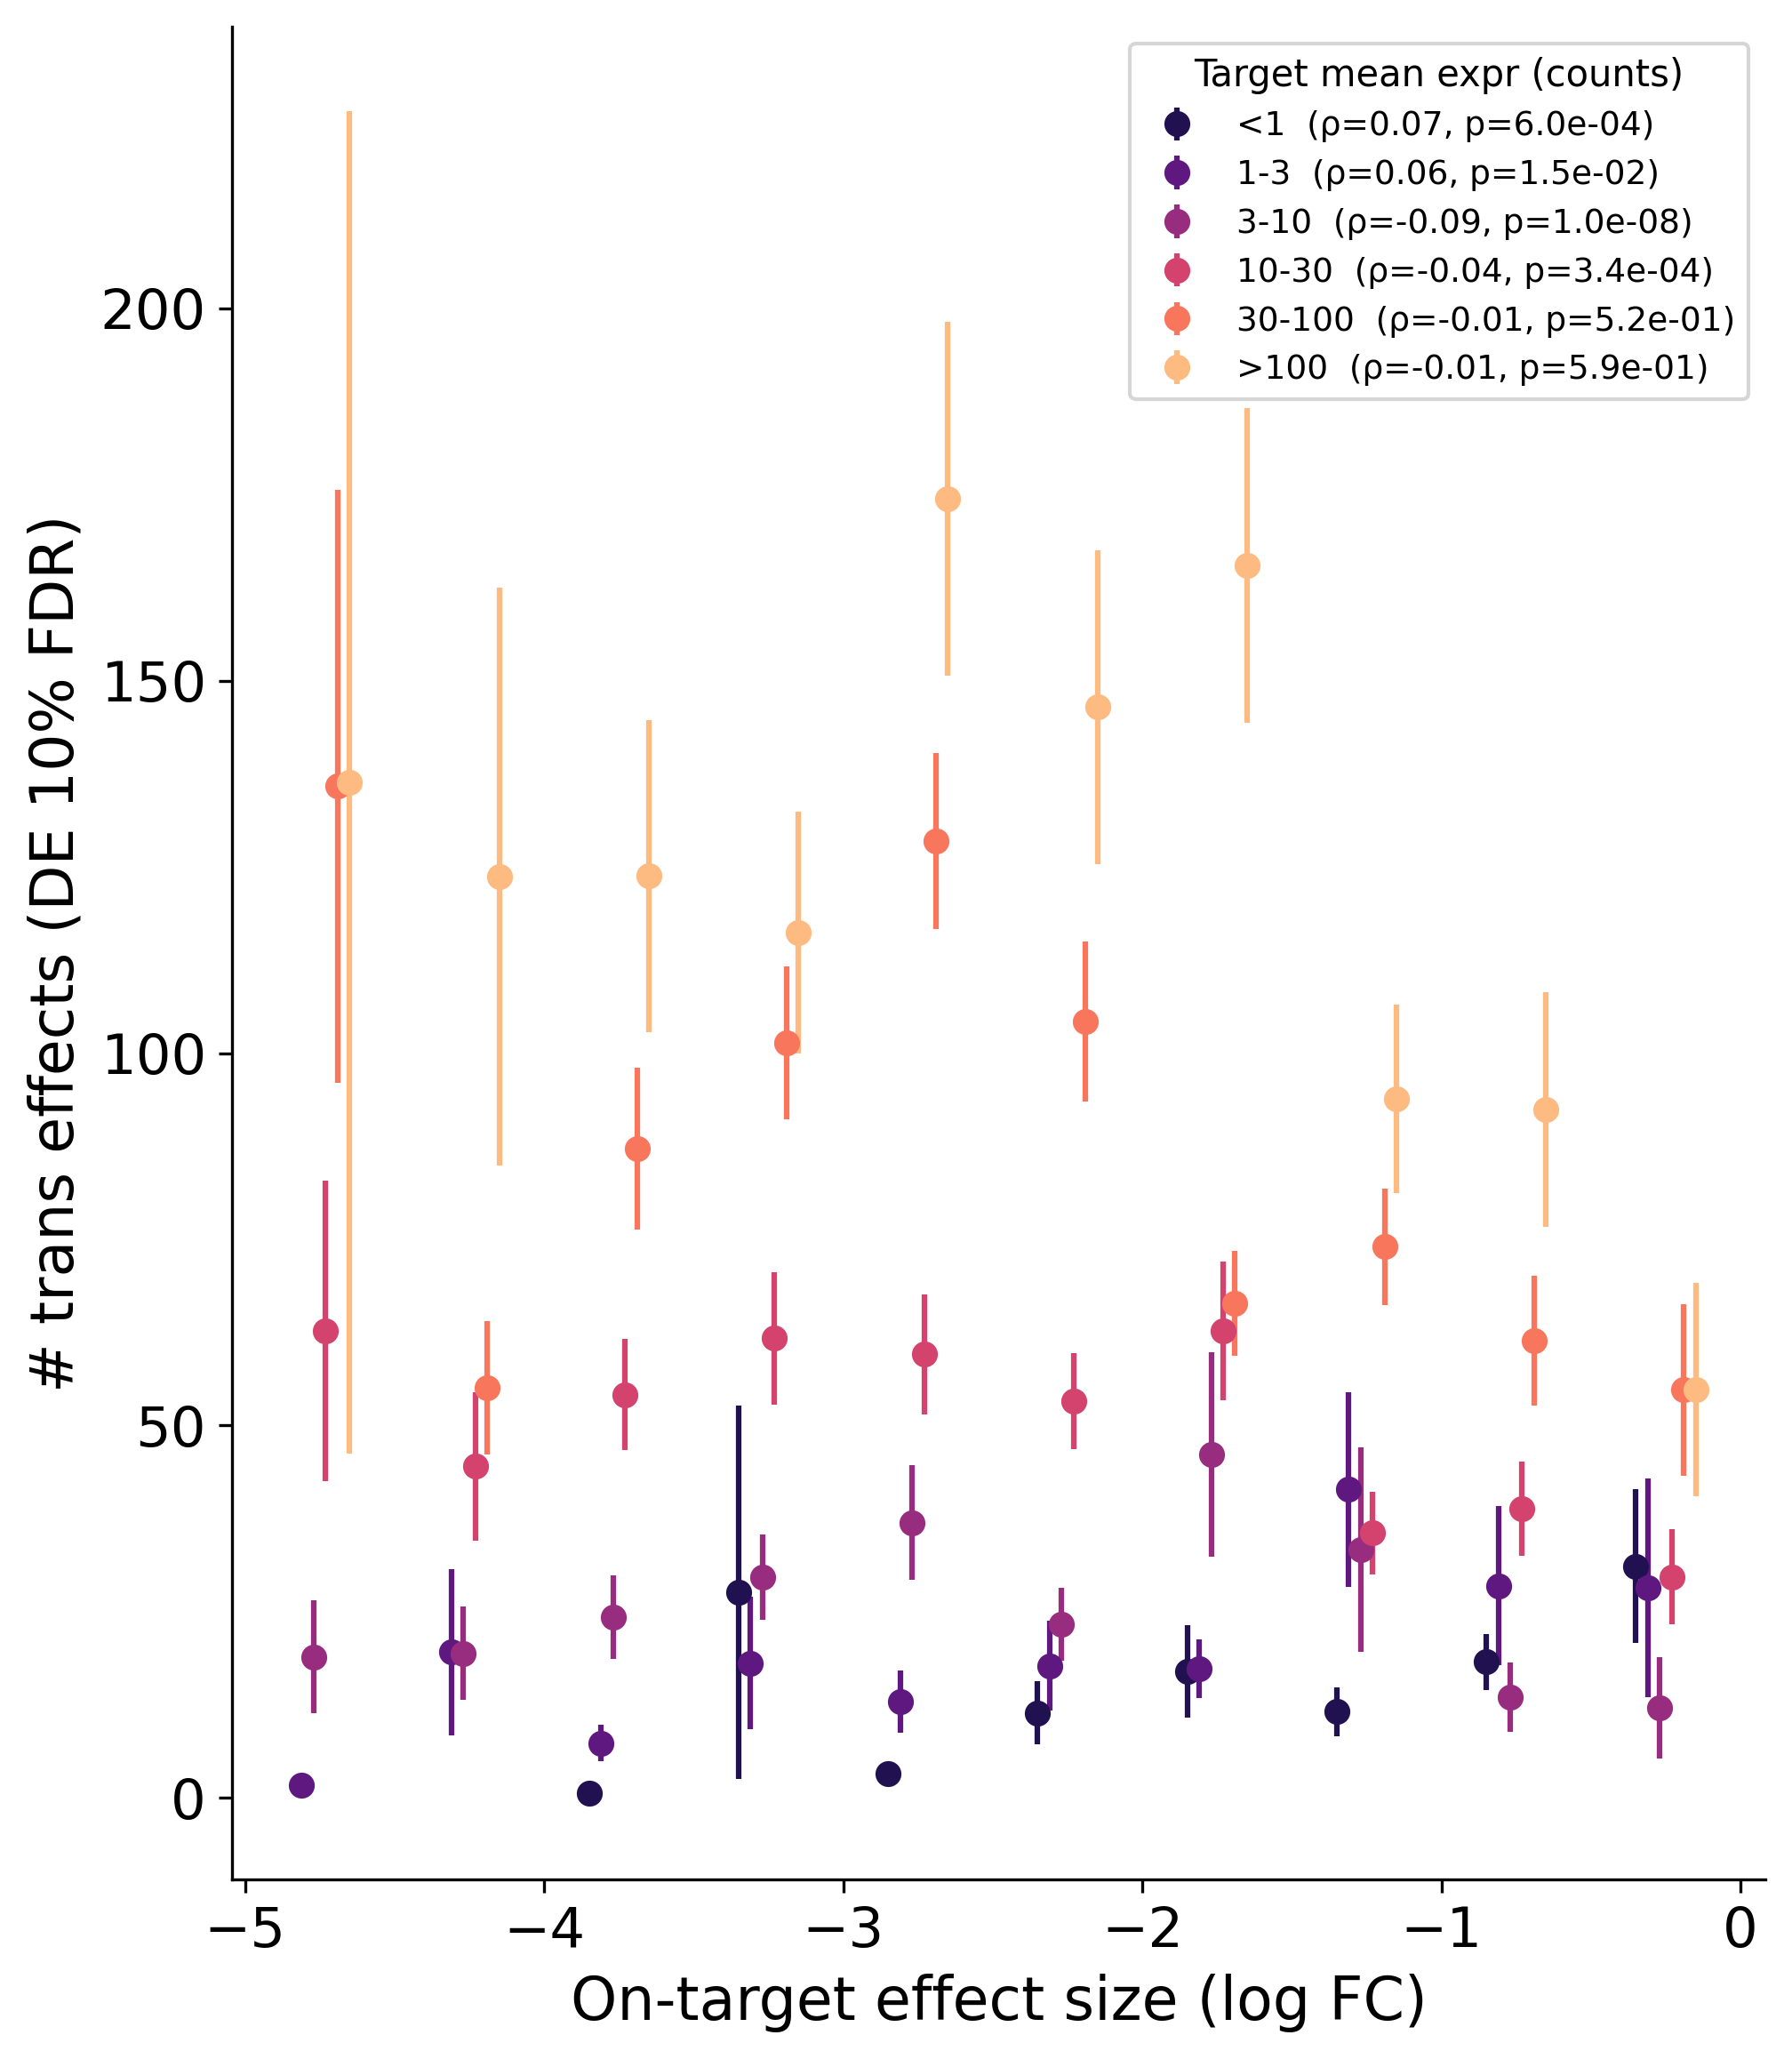

In [209]:
pl_df = pd.merge(de_counts.rename(columns={'condition':'culture_condition'}), ontarget_df[['target_contrast', 'culture_condition', 'log_fc', 'adj_p_value']])

# Bin baseMean and compute mean DE genes by on-target LFC bin, stratified by baseMean bin
pl_df['baseMean_bin'] = pd.cut(
    np.log10(pl_df['baseMean']),
    bins=[-np.inf, 0.1, 0.5, 1, 1.5, 2, np.inf],
    labels=['<1', '1-3', '3-10', '10-30', '30-100', '>100']
)

lfc_vals = pl_df['ontarget_effect_size_lfc'].clip(lower=-5, upper=0)
lfc_bins = np.linspace(-5, 0, 11)  # 10 equal-width bins between -5 and 0
pl_df['lfc_bin'] = pd.cut(lfc_vals, bins=lfc_bins, include_lowest=True)

mean_df = (
    pl_df.groupby(['baseMean_bin', 'lfc_bin'], observed=True)['n_total_de_genes']
    .agg(mean_n_de='mean', n_points='count', sem_n_de=lambda x: x.sem())
    .reset_index()
)
mean_df['lfc_bin_mid'] = mean_df['lfc_bin'].apply(lambda x: x.mid)

# Spearman correlation per baseMean_bin (on raw data)
spearman_per_bin = {}
for b, grp in pl_df.groupby('baseMean_bin', observed=True):
    valid = grp[['ontarget_effect_size_lfc', 'n_total_de_genes']].dropna()
    if len(valid) > 1:
        r, p = stats.spearmanr(valid['ontarget_effect_size_lfc'], valid['n_total_de_genes'])
        spearman_per_bin[b] = (r, p)

fig, ax = plt.subplots(figsize=(7, 8))
palette = sns.color_palette("magma", n_colors=pl_df['baseMean_bin'].nunique())
basemean_bins = pl_df['baseMean_bin'].cat.categories
n_groups = len(basemean_bins)
dodge_offsets = np.linspace(-0.1, 0.1, n_groups)

for offset, color, (b, grp) in zip(dodge_offsets, palette, mean_df.groupby('baseMean_bin', observed=True)):
    grp = grp.sort_values('lfc_bin_mid')
    r, p = spearman_per_bin.get(b, (float('nan'), float('nan')))
    label = f"{b}  (ρ={r:.2f}, p={p:.1e})"
    ax.errorbar(
        grp['lfc_bin_mid'].astype(float) + offset, grp['mean_n_de'], yerr=grp['sem_n_de'],
        fmt='o', color=color,
        label=label,
        capsize=0, linestyle='none'
    )

ax.set_xlabel('On-target effect size (log FC)', fontsize=16)
ax.set_ylabel('# trans effects (DE 10% FDR)', fontsize=16)
ax.legend(title='Target mean expr (counts)', fontsize=9, title_fontsize=10, loc='upper right')
sns.despine()
plt.tight_layout()
plt.savefig('./results/mean_de_genes_by_lfc_bin.pdf', bbox_inches='tight')

In [202]:
mean_df

,baseMean_bin,lfc_bin,mean_n_de,n_points,sem_n_de,lfc_bin_mid
0,<1,"(-4.0, -3.5]",0.666667,3,0.333333,-3.7500
1,<1,"(-3.5, -3.0]",27.606061,33,25.091044,-3.2500
2,<1,"(-3.0, -2.5]",3.290000,100,1.020823,-2.7500
3,<1,"(-2.5, -2.0]",11.398374,246,4.224670,-2.2500
4,<1,"(-2.0, -1.5]",16.945026,382,6.211649,-1.7500
5,<1,"(-1.5, -1.0]",11.557087,508,3.323267,-1.2500
6,<1,"(-1.0, -0.5]",18.248299,588,3.729598,-0.7500
7,<1,"(-0.5, 0.0]",31.108844,441,10.342840,-0.2500
8,1-3,"(-5.001, -4.5]",1.714286,7,0.521641,-4.7505
9,1-3,"(-4.5, -4.0]",19.594595,37,11.157113,-4.2500


In [17]:
pl_df[['baseMean_bin', 'culture_condition']].value_counts()

baseMean_bin  culture_condition
10-100        Rest                 5532
              Stim48hr             5402
              Stim8hr              5343
<10           Rest                 2870
              Stim8hr              2619
              Stim48hr             2344
> 100         Stim48hr             1593
              Stim8hr              1479
              Rest                  951
Name: count, dtype: int64

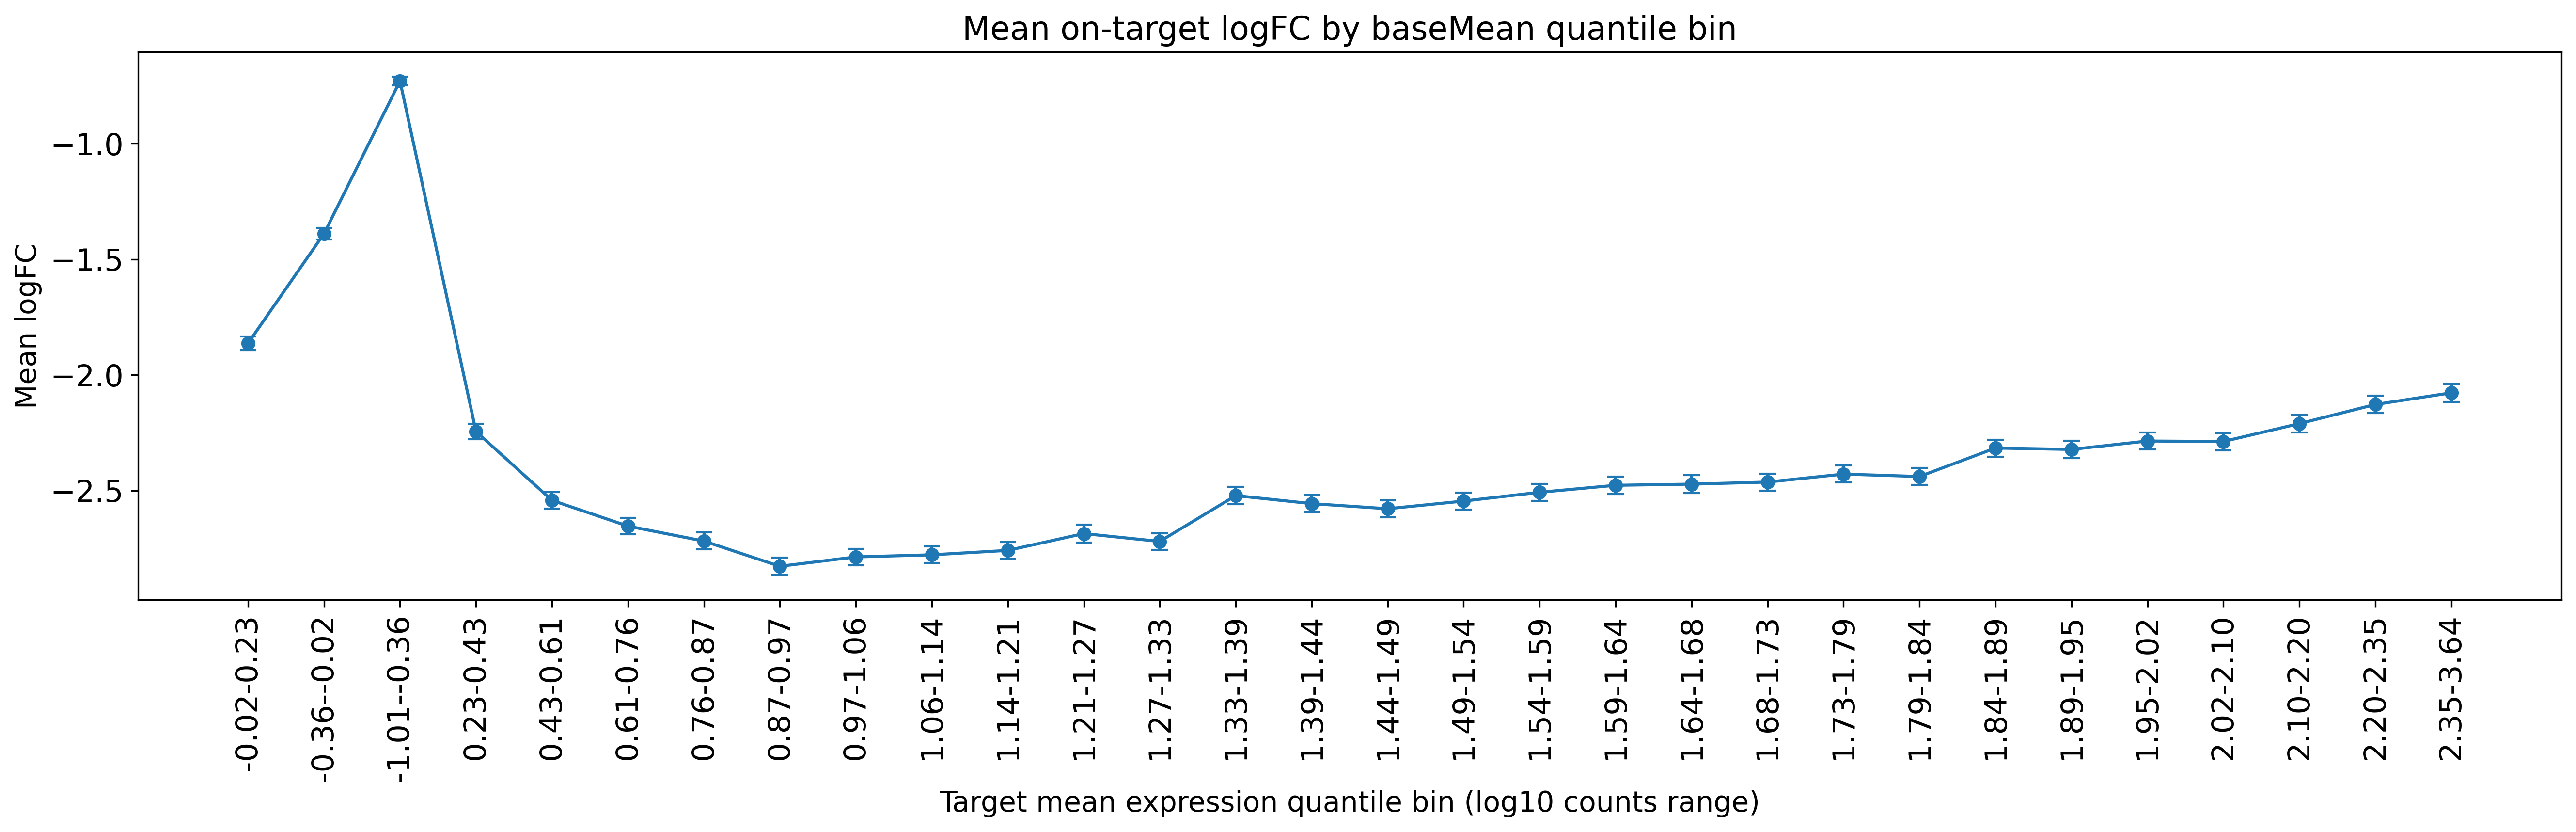

In [25]:
# Plot 30 quantile bins of baseMean on the x-axis and mean log_fc on y-axis

quantiles = 30
pl_df = pd.merge(
    de_counts.rename(columns={'condition': 'culture_condition'}),
    ontarget_df[['target_contrast', 'culture_condition', 'log_fc', 'adj_p_value']]
).copy()

# Drop NA in baseMean/log_fc as needed for binning and means
pl_df = pl_df[pl_df['baseMean'].notna() & pl_df['log_fc'].notna()].copy()

# Bin baseMean (log10) into quantile bins
pl_df['baseMean_quantile_bin'], bin_edges = pd.qcut(
    np.log10(pl_df['baseMean']), 
    q=quantiles, 
    retbins=True, 
    labels=False, 
    duplicates='drop'
)

# Create bin labels for the x-axis (show left and right edge for clarity)
bin_labels = [
    f"{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}" 
    for i in range(len(bin_edges) - 1)
]
pl_df['baseMean_quantile_bin_label'] = pl_df['baseMean_quantile_bin'].map(
    lambda x: bin_labels[int(x)] if not pd.isnull(x) else np.nan
)

# Group by baseMean bin and compute mean log_fc for each bin
grouped = pl_df.groupby('baseMean_quantile_bin_label').agg(
    mean_log_fc = ('log_fc', 'mean'),
    std_log_fc  = ('log_fc', 'std'),
    count       = ('log_fc', 'count')
).reset_index()

# Plot mean log_fc by baseMean quantile bin
plt.figure(figsize=(18, 6))
ax = plt.gca()
x = np.arange(len(grouped))
y = grouped['mean_log_fc']
yerr = grouped['std_log_fc'] / grouped['count']**0.5  # Standard error

ax.errorbar(
    x, y, yerr=yerr, fmt='-o', capsize=4, color='tab:blue'
)
ax.set_xticks(x)
ax.set_xticklabels(grouped['baseMean_quantile_bin_label'], rotation=90)
ax.set_xlabel('Target mean expression quantile bin (log10 counts range)', fontsize=14)
ax.set_ylabel('Mean logFC', fontsize=14)
ax.set_title("Mean on-target logFC by baseMean quantile bin", fontsize=16)

plt.tight_layout()